# 외전형 36슬롯 30극 Hairpin PMSM의 Radial 및 3분할 Halbach 배열 종합 전자기 성능 비교

### FEMM 정자계 기반 0–50 A 포화, 회전자 위치별 토크 및 백아이언 두께 설계

동일한 외전형 SPM에서 일반 방사형 자석 배열과 3분할 quasi-Halbach 배열을 비교한다. 분석 범위는 무부하·1 A 기준 자속과 토크, 1–50 A 비선형 포화, 한 전기주기 위치 평균토크와 리플, 회전자 백아이언 1.50–5.00 mm 두께 스윕까지 포함한다.

## 0. 핵심 요약

- Halbach는 공극 기본파를 약 1.5% 높이고 외부 누설자속을 약 58% 줄인다.
- 15 A 정밀 위치 스윕에서 Halbach 평균토크는 3.33% 높고 피크투피크 토크리플은 53.48% 낮다.
- 0–50 A 위치 통합 해석에서 두 설계 모두 포화에 따라 증분토크가 약 27–29% 감소하지만 평균토크는 계속 증가한다.
- 동일한 5 mm 백아이언에서는 Halbach의 토크 이득만으로 공정비 증가를 정당화하기 어렵다.
- Halbach의 낮은 회전자 요크 자속을 활용하면 더 얇은 백아이언과 낮은 회전자 질량·관성을 검토할 수 있다.
- 현재 데이터가 제시하는 두께 검토 범위는 Radial 3.75–4.00 mm, Halbach 2.50–2.75 mm다. 1.6/1.7 T는 확정 합격선이 아니라 설계 참고선이다.

## 목차

1. 해석 대상과 공통 조건
2. 자석 배열과 자속 경로
3. 무부하 및 저전류 기준 성능
4. 초기 1–15 A 비선형 포화 분석
5. 15 A 회전자 위치별 토크 특성
6. 0–50 A 전류–위치 통합 분석
7. 백아이언 50% 축소 검증
8. 백아이언 전체 두께 스윕과 경계안 검증
9. 종합 설계 판단
10. 해석 한계와 후속 검증
11. 부록: 지표 정의와 데이터 구성

## 1. 해석 대상과 공통 조건

### 1.1 분석 목적

동일한 자석 두께와 극호율을 갖는 Radial 및 3분할 quasi-Halbach 외전형 모터를 비교해 자석 배열이 토크, 리플, 누설자속, 철심 포화와 백아이언 축소 가능성에 미치는 영향을 확인한다.

### 1.2 공통 모델

| 항목 | 조건 |
|---|---:|
| 구조 | 외전형 SPM, 36슬롯 / 30극 |
| 적층 길이 | 150 mm |
| 공극 | 0.7 mm |
| 권선 | 슬롯당 2열 × 6층 Hairpin |
| 자석 | N35, 동일 자석 반경 및 극호율 |
| 해석 | 2D FEMM 정자계, 비선형 철심 B–H 적용 |
| 전류 | 평형 3상 q축, 상전류 피크 기준 |

### 1.3 해석 매트릭스

| 단계 | 전류 | 회전자 위치 | 목적 |
|---|---:|---:|---|
| 무부하·기준점 | 0 A, 1 A | 단일 위치 | 영구자석 자속과 저전류 토크 |
| 초기 포화 스윕 | 1–15 A, 1 A 간격 | 단일 위치 | 비선형성의 초기 탐색 |
| 정밀 위치 스윕 | 15 A | 0–10°, 0.2° | 평균토크와 정밀 리플 |
| 통합 스윕 | 0–20 A는 1 A, 22–50 A는 2 A 간격 | 0–12°, 1° | 포화와 위치 평균의 결합 |
| 백아이언 스윕 | 50 A | 0° 및 경계안 0–12° | 1.50–5.00 mm 두께 검토 |

1 A 조건의 순간 상전류는 $I_A=0$, $I_B=+0.866$, $I_C=-0.866$ A다. 모든 부하 조건은 세 상 합이 0인 평형 전류이며 회전자 자속에 대해 토크를 생성하도록 q축 위상을 동기 이동했다.

## 2. 자석 배열과 자속 경로

아래 도면은 두 FEM 모델의 차이를 쉽게 보기 위한 단순화 단면도다. 회색 부분은 철심, 색칠된 바깥쪽 조각은 영구자석이며 검은 화살표는 자화 방향을 나타낸다.

- **Radial magnets:** 한 극을 하나의 자석으로 구성하며 자화 방향이 안쪽 또는 바깥쪽 반경 방향이다.
- **3-segment quasi-Halbach:** 한 극을 세 조각으로 나누고 `경사–방사–경사` 방향으로 자화한다. 완전한 연속 Halbach를 제조 가능한 세 조각으로 근사한 구조다.
- 두 설계는 자석 두께와 극호율을 동일하게 유지했으므로 자석 사용량을 크게 바꾸지 않은 배열 효과 비교다.

> 이 그림은 자화 개념을 보여주는 설명용 도면이다. 치수와 슬롯·도체 형상은 실제 `.fem` 모델에 들어 있다.

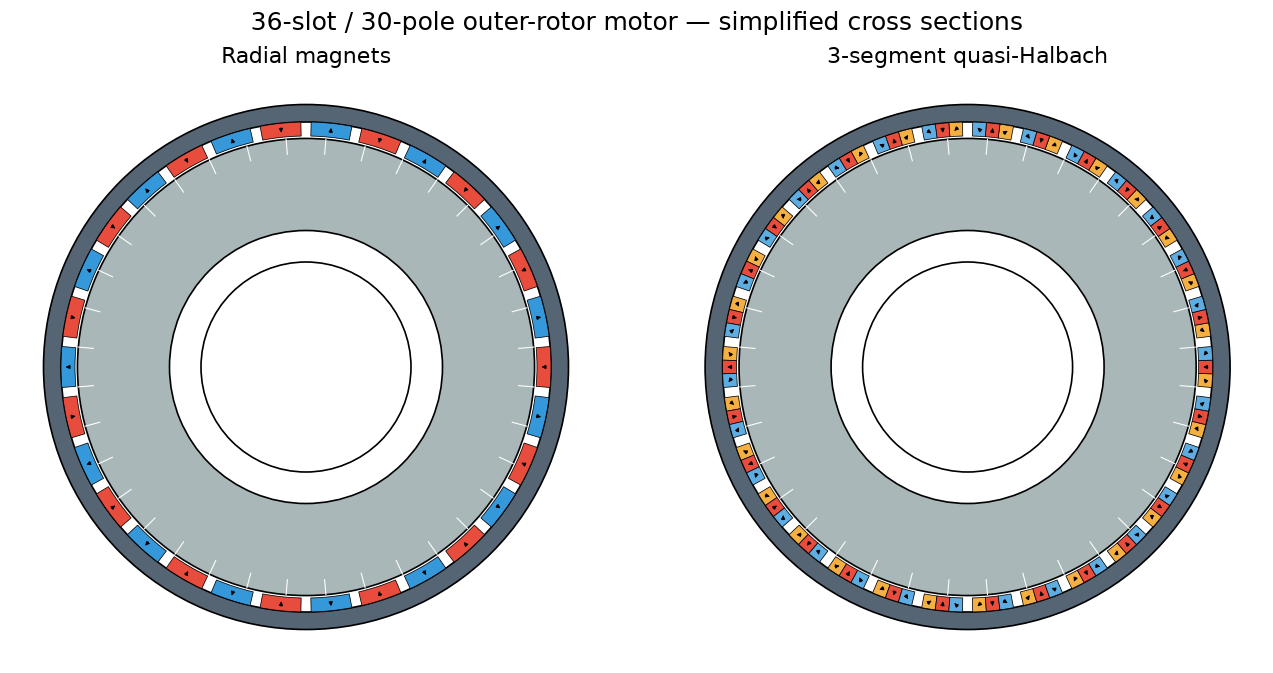

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge, FancyArrowPatch
from IPython.display import display, Markdown

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "font.size": 10})
ROOT = Path.cwd().parent if Path.cwd().name == "analysis_results" else Path.cwd()
DATA = ROOT / "outer_rotor_36s30p_hairpin"

def polar(r, deg):
    a = np.deg2rad(deg)
    return r*np.cos(a), r*np.sin(a)

def motor_drawing(ax, halbach=False):
    # Simplified manufacturing-oriented cross section; dimensions are in mm.
    ax.add_patch(Wedge((0, 0), 75, 0, 360, width=5, facecolor="#566573", edgecolor="black"))
    ax.add_patch(Wedge((0, 0), 65.3, 0, 360, width=26.3, facecolor="#aab7b8", edgecolor="black"))
    ax.add_patch(Circle((0, 0), 30, facecolor="white", edgecolor="black"))
    pole_pitch = 12
    pole_arc = 9.6
    for pole in range(30):
        center = pole*pole_pitch
        nseg = 3 if halbach else 1
        for seg in range(nseg):
            a0 = center-pole_arc/2 + seg*pole_arc/nseg
            a1 = center-pole_arc/2 + (seg+1)*pole_arc/nseg
            color = ("#e74c3c" if pole % 2 == 0 else "#3498db") if not halbach else ["#f5b041", "#e74c3c", "#5dade2"][seg]
            ax.add_patch(Wedge((0, 0), 70, a0, a1, width=4, facecolor=color, edgecolor="black", linewidth=.45))
            amid = (a0+a1)/2
            if halbach:
                magdir = (16*amid + 180) % 360
            else:
                magdir = (center + (180 if pole % 2 == 0 else 0)) % 360
            x, y = polar(68, amid)
            dx, dy = 3.3*np.cos(np.deg2rad(magdir)), 3.3*np.sin(np.deg2rad(magdir))
            ax.add_patch(FancyArrowPatch((x-dx/2, y-dy/2), (x+dx/2, y+dy/2),
                                         arrowstyle="-|>", mutation_scale=5, color="black", linewidth=.55))
    # Representative slot openings, kept light so the magnet arrangement stays readable.
    for slot in range(36):
        a = slot*10 + 5
        x0, y0 = polar(61, a); x1, y1 = polar(65.3, a)
        ax.plot([x0, x1], [y0, y1], color="white", linewidth=.65)
    ax.set(xlim=(-84, 84), ylim=(-84, 84), aspect="equal")
    ax.axis("off")
    ax.set_title("Radial magnets" if not halbach else "3-segment quasi-Halbach")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), constrained_layout=True)
motor_drawing(axes[0], False)
motor_drawing(axes[1], True)
fig.suptitle("36-slot / 30-pole outer-rotor motor — simplified cross sections", fontsize=15)
plt.show()

## 3. 무부하 및 저전류 기준 성능

### 3.1 1 A 정적 토크 기준점

아래 표는 동일한 정적 회전자 위치와 동일한 q축 전류에서 얻은 결과다. `Change (%)`는 방사형 자석 모델을 기준으로 계산한다.

토크는 회전자 전체 자석·철심 그룹에 대한 FEMM 토크 적분값이다. 이 값은 한 회전자 위치에서의 **정적 토크**이므로, 한 전기주기의 평균토크나 토크리플과 동일하지 않다.

In [2]:
metrics_path = DATA / "radial_halbach_1A_qaxis_metrics.csv"
waveforms_path = DATA / "radial_halbach_1A_qaxis_waveforms.csv"
metrics = pd.read_csv(metrics_path).set_index("metric")
waveforms = pd.read_csv(waveforms_path)

summary = pd.DataFrame({
    "Radial": [metrics.loc["torque_Nm", "radial"], metrics.loc["gap_fundamental_peak_T", "radial"],
               metrics.loc["gap_thd", "radial"], metrics.loc["leakage_rms_T", "radial"]],
    "3-seg Halbach": [metrics.loc["torque_Nm", "halbach_3seg"], metrics.loc["gap_fundamental_peak_T", "halbach_3seg"],
                      metrics.loc["gap_thd", "halbach_3seg"], metrics.loc["leakage_rms_T", "halbach_3seg"]],
    "Change (%)": [metrics.loc["torque_Nm", "change_percent"], metrics.loc["gap_fundamental_peak_T", "change_percent"],
                   metrics.loc["gap_thd", "change_percent"], metrics.loc["leakage_rms_T", "change_percent"]],
}, index=["Torque (N·m)", "Air-gap fundamental peak (T)", "Air-gap THD", "External leakage RMS (T)"])
display(summary.style.format({"Radial": "{:.6g}", "3-seg Halbach": "{:.6g}", "Change (%)": "{:+.2f}"}))

,Radial,3-seg Halbach,Change (%)
Torque (N·m),1.60944,1.86373,+15.80
Air-gap fundamental peak (T),1.10515,1.12209,+1.53
Air-gap THD,0.218301,0.235745,+7.99
External leakage RMS (T),4.30359e-05,1.81362e-05,-57.86


### 3.2 1 A 토크 해석

- 방사형 자석 모델: **1.609 N·m**
- 3분할 Halbach 모델: **1.864 N·m**
- 동일 전류에서 Halbach 토크가 **15.8% 증가**했다.

공극 기본파 증가는 약 1.53%인데 정적 토크 증가는 더 크게 나타났다. 이는 단일 위치에서 슬롯팅, 고조파 및 자속 분포가 토크 적분에 함께 작용하기 때문이다. 따라서 이 차이를 곧바로 전 운전영역의 평균토크 증가율로 해석하면 안 되며, 추후 회전자 위치 스윕으로 검증해야 한다.

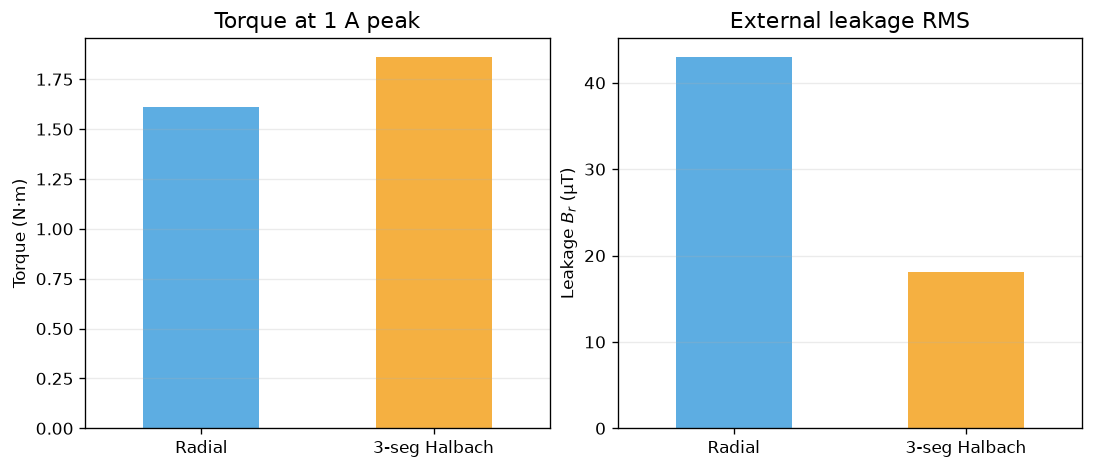

In [3]:
torque = summary.loc["Torque (N·m)", ["Radial", "3-seg Halbach"]]
leak = 1e6*summary.loc["External leakage RMS (T)", ["Radial", "3-seg Halbach"]]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
torque.plot.bar(ax=axes[0], color=["#5dade2", "#f5b041"], rot=0, title="Torque at 1 A peak")
axes[0].set_ylabel("Torque (N·m)"); axes[0].grid(axis="y", alpha=.25)
leak.plot.bar(ax=axes[1], color=["#5dade2", "#f5b041"], rot=0, title="External leakage RMS")
axes[1].set_ylabel("Leakage $B_r$ (µT)"); axes[1].grid(axis="y", alpha=.25)
plt.show()

### 3.3 공극 자속밀도 $B_r$ 및 외부 누설자속

왼쪽 그래프는 공극 중앙 반경에서 측정한 방사방향 자속밀도 $B_r$이다. 오른쪽 그래프는 회전자 바깥쪽 $r=78$ mm 위치에서 측정한 외부 누설자속이다.

### 그래프를 읽는 방법

- 공극 $B_r$의 기본파는 유효 역기전력과 주 토크 생성 자속에 관계한다.
- THD는 기본파를 제외한 공간고조파의 상대 크기다. 작을수록 파형이 정현파에 가깝다.
- 외부 누설 RMS는 모터 바깥으로 빠져나가는 자계의 전체적인 크기를 나타낸다.

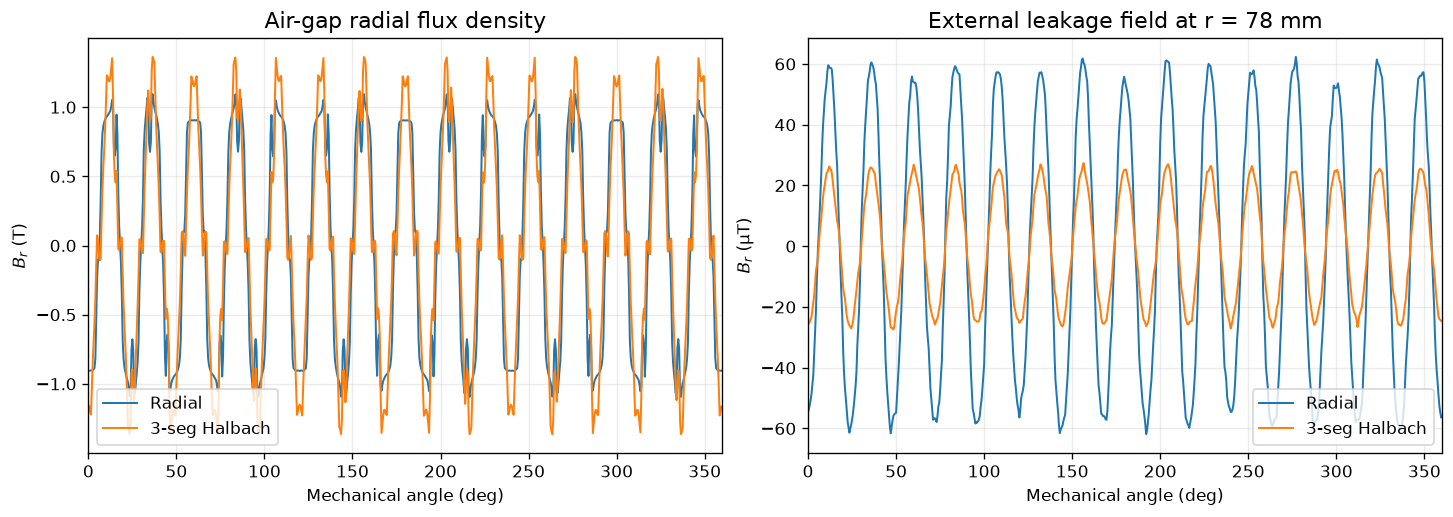

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

angle = waveforms["mechanical_angle_deg"]
axes[0].plot(angle, waveforms["radial_gap_Br_T"], label="Radial", lw=1.2)
axes[0].plot(angle, waveforms["halbach_gap_Br_T"], label="3-seg Halbach", lw=1.2)
axes[0].set(title="Air-gap radial flux density", xlabel="Mechanical angle (deg)", ylabel="$B_r$ (T)", xlim=(0, 360))
axes[0].grid(alpha=.25); axes[0].legend()

axes[1].plot(angle, 1e6*waveforms["radial_external_Br_T"], label="Radial", lw=1.2)
axes[1].plot(angle, 1e6*waveforms["halbach_external_Br_T"], label="3-seg Halbach", lw=1.2)
axes[1].set(title="External leakage field at r = 78 mm", xlabel="Mechanical angle (deg)", ylabel="$B_r$ (µT)", xlim=(0, 360))
axes[1].grid(alpha=.25); axes[1].legend()
plt.show()

### 3.4 저전류 자속 결과 해석

- 공극 기본파 피크: **1.105 T → 1.122 T**, 약 **1.53% 증가**
- 공극 THD: **0.218 → 0.236**, 약간 악화
- 외부 누설자속 RMS: **43.0 µT → 18.1 µT**, 약 **57.9% 감소**

따라서 이 설계에서 3분할 Halbach의 가장 뚜렷한 효과는 공극 기본파의 큰 증가가 아니라 **회전자 외부 누설자속 억제**다. 공극 파형의 일부 국부 피크와 고조파는 증가했으므로, 손실과 토크리플 측면에서는 별도 확인이 필요하다.

## 4. 초기 1–15 A 비선형 포화 분석

두 설계를 동일한 정적 회전자 위치와 동일한 q축 전류 조건에서 1–15 A까지 1 A 간격으로 해석했다. 각 전류점은 독립 FEM 해석이며 총 30개 케이스가 모두 완료되었다.

### 판단 지표

- **토크 $T$:** 같은 전류에서 얻는 절대 출력
- **토크/A $T/I$:** 전류 이용률과 포화에 따른 저하 경향
- **증분토크 $\Delta T/\Delta I$:** 전류를 추가했을 때 실제로 늘어난 토크
- **고정자·회전자 최대 샘플 자속밀도:** 철심의 국부 포화 경향
- **외부 누설 RMS:** 회전자 바깥으로 빠지는 자계

> 주의: 이 결과는 한 회전자 위치의 정적 q축 토크 비교다. 평균토크와 토크리플을 확정하려면 회전자 위치 스윕이 별도로 필요하다.

In [5]:
sweep_path = DATA / "current_saturation_1to15A" / "current_saturation_sweep.csv"
sweep = pd.read_csv(sweep_path).sort_values(["design", "current_peak_A"]).reset_index(drop=True)

expected = {(d, i) for d in ["radial", "halbach_3seg"] for i in range(1, 16)}
actual = set(zip(sweep["design"], sweep["current_peak_A"].astype(int)))
assert actual == expected, f"Missing or unexpected cases: {sorted(expected ^ actual)}"
assert sweep[list(sweep.select_dtypes(include=np.number).columns)].notna().all().all()

radial = sweep[sweep.design == "radial"].set_index("current_peak_A")
halbach = sweep[sweep.design == "halbach_3seg"].set_index("current_peak_A")

comparison = pd.DataFrame({
    "Radial torque (N·m)": radial.torque_Nm,
    "Halbach torque (N·m)": halbach.torque_Nm,
})
comparison["Halbach gain (N·m)"] = comparison["Halbach torque (N·m)"] - comparison["Radial torque (N·m)"]
comparison["Halbach gain (%)"] = 100 * (comparison["Halbach torque (N·m)"] / comparison["Radial torque (N·m)"] - 1)
display(comparison.loc[[1, 5, 10, 15]].style.format("{:.3f}"))

print(f"Completed cases: {len(sweep)} / 30")
print(f"15 A torque gain: {comparison.loc[15, 'Halbach gain (N·m)']:.3f} N·m "
      f"({comparison.loc[15, 'Halbach gain (%)']:.2f}%)")

,Radial torque (N·m),Halbach torque (N·m),Halbach gain (N·m),Halbach gain (%)
current_peak_A,,,,
1,1.609,1.864,0.254,15.800
5,8.430,9.211,0.781,9.262
10,16.895,18.285,1.389,8.224
15,25.234,26.996,1.762,6.983


Completed cases: 30 / 30
15 A torque gain: 1.762 N·m (6.98%)


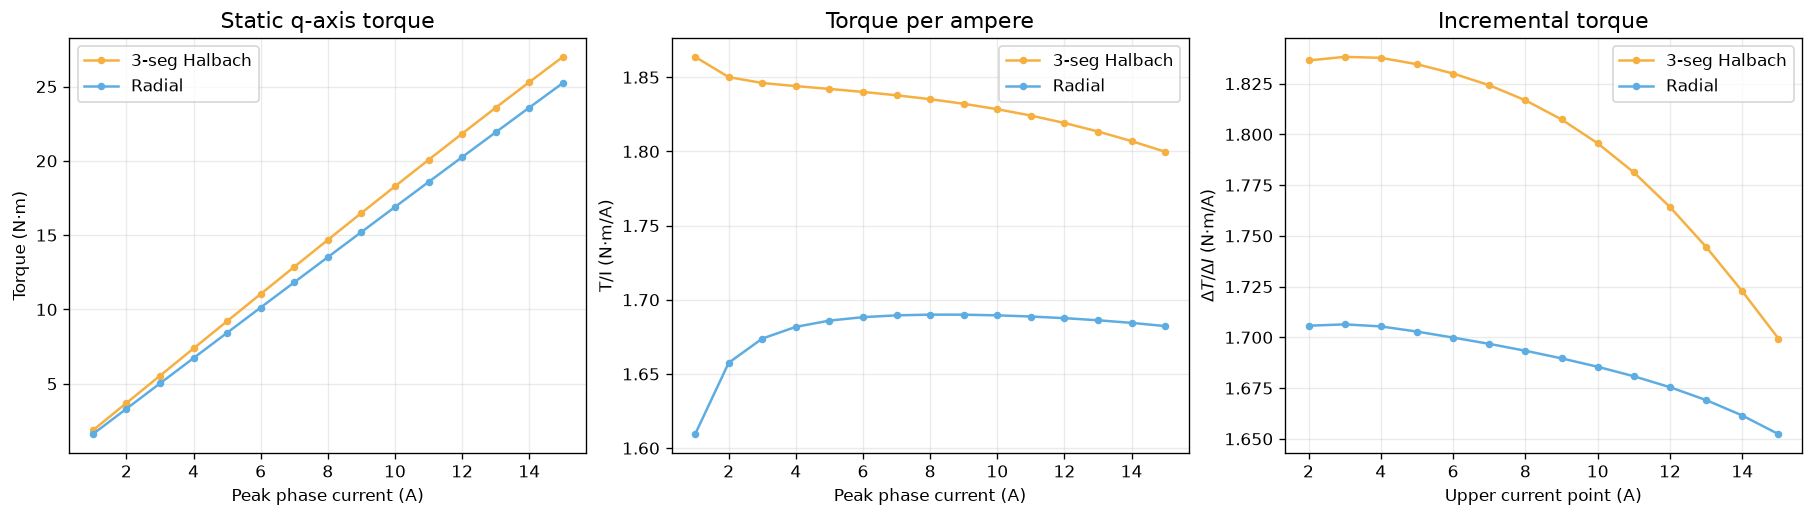

In [6]:
colors = {"radial": "#5dade2", "halbach_3seg": "#f5b041"}
labels = {"radial": "Radial", "halbach_3seg": "3-seg Halbach"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for design, group in sweep.groupby("design", sort=False):
    g = group.sort_values("current_peak_A")
    current = g.current_peak_A.to_numpy()
    torque_values = g.torque_Nm.to_numpy()
    axes[0].plot(current, torque_values, "o-", ms=3.5, color=colors[design], label=labels[design])
    axes[1].plot(current, g.torque_per_A_Nm_per_A, "o-", ms=3.5, color=colors[design], label=labels[design])
    axes[2].plot(current[1:], np.diff(torque_values), "o-", ms=3.5, color=colors[design], label=labels[design])

axes[0].set(title="Static q-axis torque", xlabel="Peak phase current (A)", ylabel="Torque (N·m)")
axes[1].set(title="Torque per ampere", xlabel="Peak phase current (A)", ylabel="T/I (N·m/A)")
axes[2].set(title="Incremental torque", xlabel="Upper current point (A)", ylabel=r"$\Delta T/\Delta I$ (N·m/A)")
for ax in axes:
    ax.grid(alpha=.25)
    ax.legend()
plt.show()

### 4.1 토크와 포화 해석

- Halbach는 **1–15 A 전 구간에서 더 큰 정적 토크**를 냈다.
- 15 A에서 방사형은 **25.234 N·m**, Halbach는 **26.996 N·m**로 Halbach가 **1.762 N·m (+6.98%)** 높다.
- Halbach의 상대 토크 이득은 1 A의 **15.80%**에서 15 A의 **6.98%**로 감소한다. 전류가 높아질수록 Halbach의 추가 이득이 줄어드는 모습이다.
- 방사형 $T/I$는 8 A에서 최대 **1.690 N·m/A**이고 15 A에서 **1.682 N·m/A**로 최대점 대비 **0.46%** 감소했다.
- Halbach $T/I$는 1 A의 **1.864 N·m/A**에서 15 A의 **1.800 N·m/A**로 **3.43%** 감소했다.
- 10–15 A 평균 증분토크는 방사형 **1.668 N·m/A**, Halbach **1.742 N·m/A**다. Halbach의 증가율이 둔화되어도 절대 증분토크는 아직 더 크다.

따라서 15 A까지는 심각한 토크 붕괴가 없지만, **Halbach가 상대적으로 더 뚜렷한 포화/비선형 경향**을 보인다.

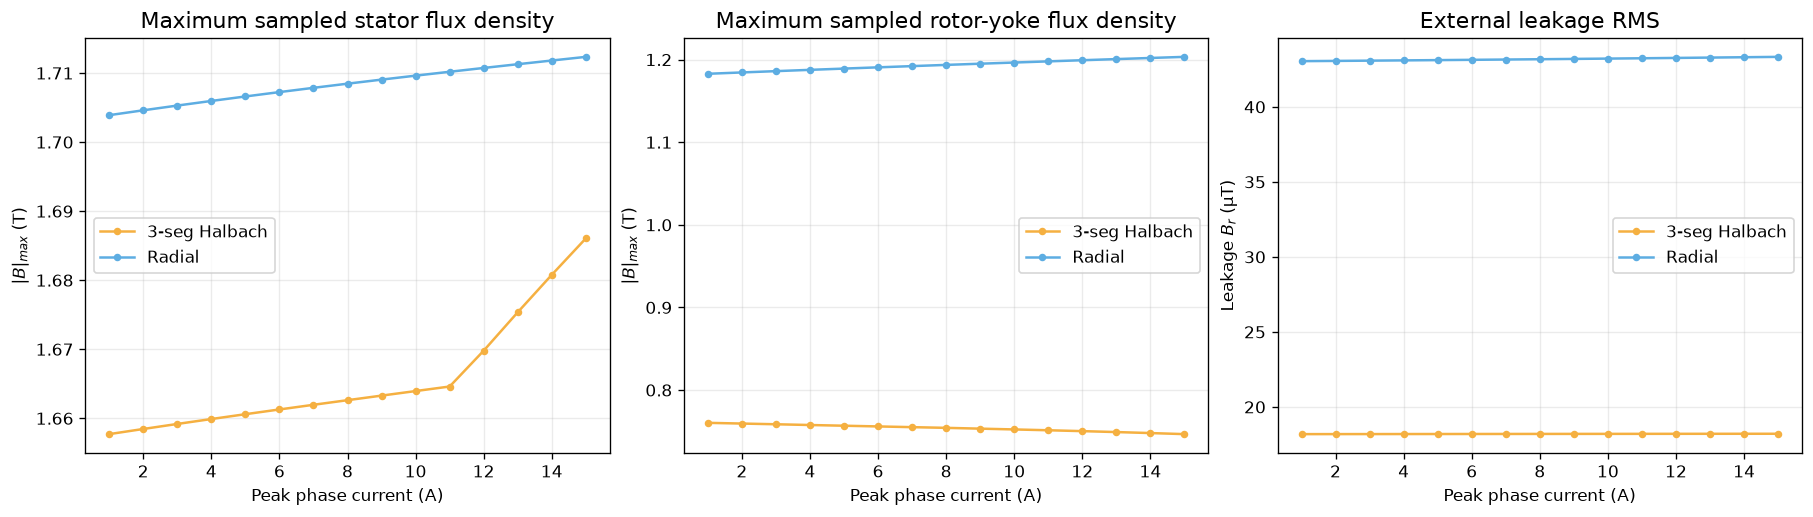

,Radial,3-seg Halbach,Halbach change (%)
Stator max sampled B (T),1.712,1.686,-1.535
Rotor-yoke max sampled B (T),1.203,0.747,-37.952
External leakage RMS (µT),43.331,18.212,-57.971


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for design, group in sweep.groupby("design", sort=False):
    g = group.sort_values("current_peak_A")
    x = g.current_peak_A
    axes[0].plot(x, g.stator_sample_max_B_T, "o-", ms=3.5, color=colors[design], label=labels[design])
    axes[1].plot(x, g.rotor_yoke_sample_max_B_T, "o-", ms=3.5, color=colors[design], label=labels[design])
    axes[2].plot(x, 1e6*g.external_leakage_rms_T, "o-", ms=3.5, color=colors[design], label=labels[design])

axes[0].set(title="Maximum sampled stator flux density", xlabel="Peak phase current (A)", ylabel="$|B|_{max}$ (T)")
axes[1].set(title="Maximum sampled rotor-yoke flux density", xlabel="Peak phase current (A)", ylabel="$|B|_{max}$ (T)")
axes[2].set(title="External leakage RMS", xlabel="Peak phase current (A)", ylabel="Leakage $B_r$ (µT)")
for ax in axes:
    ax.grid(alpha=.25)
    ax.legend()
plt.show()

field_15A = pd.DataFrame({
    "Radial": [radial.loc[15, "stator_sample_max_B_T"], radial.loc[15, "rotor_yoke_sample_max_B_T"], 1e6*radial.loc[15, "external_leakage_rms_T"]],
    "3-seg Halbach": [halbach.loc[15, "stator_sample_max_B_T"], halbach.loc[15, "rotor_yoke_sample_max_B_T"], 1e6*halbach.loc[15, "external_leakage_rms_T"]],
}, index=["Stator max sampled B (T)", "Rotor-yoke max sampled B (T)", "External leakage RMS (µT)"])
field_15A["Halbach change (%)"] = 100*(field_15A["3-seg Halbach"] / field_15A["Radial"] - 1)
display(field_15A.style.format("{:.3f}"))

### 4.2 철심 자속, 누설 및 FFT 해석

15 A에서 Halbach는 방사형 대비:

- 최대 고정자 샘플 자속밀도: **1.712 → 1.686 T** (**1.54% 감소**)
- 최대 회전자 요크 샘플 자속밀도: **1.203 → 0.747 T** (**37.95% 감소**)
- 외부 누설 RMS: **43.33 → 18.21 µT** (**57.97% 감소**)

Halbach는 고전류에서도 회전자 요크와 외부로 향하는 자속을 크게 줄인다. 최대 고정자 샘플 자속은 두 설계 모두 약 1.7 T 수준이므로 국부 포화 가능성은 재료의 실제 B-H 곡선과 자속밀도 분포도로 추가 확인해야 한다.

### 공극 FFT 지표에 대한 제한

기존 1 A 파형 비교는 원주 **720점**, 이번 전류 스윕은 계산시간 절감을 위해 **180점**을 사용했다. 180점 결과는 36슬롯·30극 공간고조파를 분리하기에 충분히 촘촘하지 않아 공극 기본파와 THD가 720점 결과와 정량적으로 일치하지 않는다. 따라서 이번 스윕의 공극 FFT 값은 추세 확인용이며, 설계 결론에는 사용하지 않았다. 공극 THD를 확정하려면 대표 전류점에 대해 720점 이상으로 다시 추출해야 한다.

### 4.3 초기 전류 스윕에서 얻은 판단

- Halbach는 1–15 A 단일 위치에서 더 큰 정적 토크와 훨씬 낮은 외부 누설을 보였다.
- 상대 토크 이득은 전류 증가와 함께 감소해 비선형 영향이 시작됨을 시사했다.
- 회전자 요크 자속은 Halbach가 크게 낮았지만 고정자 국부 자속은 두 설계 모두 약 1.7 T에 접근했다.
- 이 결과는 최종 선택이 아니라 후속 위치 스윕과 0–50 A 확장 해석의 출발점이다. 단일 위치 토크를 평균토크로 해석하지 않는다.

## 5. 15 A 회전자 위치별 토크 특성

단일 위치 토크를 실제 위치 평균과 구분하기 위해 두 회전자를 기계각 **0–10°**, **0.2° 간격**으로 회전했다. 각 위치에서 전류 전기각을 $\theta_e=-15\theta_m$로 동기 이동해 동일한 토크 생성 방향을 유지했다. 회전자 원호·자석 경계·재료 라벨 전체를 같은 그룹으로 회전시킨 전용 모델을 사용했다.

- 각 설계: 51점(0°와 10° 포함)
- 평균 및 리플 계산: `0 ≤ θ < 10°`의 50점 사용
- 10° 점은 반복성 확인용으로 남기고 평균에서는 제외
- 결과는 한 위치의 정적 토크가 아니라 10° 구간의 위치 평균 및 토크 변동을 나타낸다.

In [8]:
radial_pos_path = DATA / "radial_15A_position_sweep_0p2deg" / "radial_15A_torque_vs_position.csv"
halbach_pos_path = DATA / "halbach_3seg_15A_position_sweep_0p2deg_10deg" / "halbach_3seg_15A_torque_vs_position.csv"

radial_pos = pd.read_csv(radial_pos_path).sort_values("mechanical_angle_deg").reset_index(drop=True)
halbach_pos = pd.read_csv(halbach_pos_path).sort_values("mechanical_angle_deg").reset_index(drop=True)
for name, frame in {"Radial": radial_pos, "Halbach": halbach_pos}.items():
    assert len(frame) == 51, f"{name}: expected 51 points, got {len(frame)}"
    assert np.allclose(frame.mechanical_angle_deg, np.arange(0, 10.0001, 0.2))
    assert frame.torque_Nm.notna().all()

# Use the half-open interval so every sampled angle has equal weight.
r = radial_pos[radial_pos.mechanical_angle_deg < 10].copy()
h = halbach_pos[halbach_pos.mechanical_angle_deg < 10].copy()

def position_metrics(frame):
    torque = frame.torque_Nm.to_numpy()
    mean = torque.mean()
    pp = torque.max() - torque.min()
    return pd.Series({
        "Mean torque (N·m)": mean,
        "Minimum torque (N·m)": torque.min(),
        "Maximum torque (N·m)": torque.max(),
        "Peak-to-peak ripple (N·m)": pp,
        "Ripple / mean (%)": 100*pp/abs(mean),
        "Torque standard deviation (N·m)": torque.std(ddof=0),
    })

position_summary = pd.DataFrame({"Radial": position_metrics(r), "3-seg Halbach": position_metrics(h)})
position_summary["Halbach change (%)"] = 100*(position_summary["3-seg Halbach"] / position_summary["Radial"] - 1)
display(position_summary.style.format("{:.3f}"))

,Radial,3-seg Halbach,Halbach change (%)
Mean torque (N·m),25.129,25.964,3.325
Minimum torque (N·m),22.538,24.909,10.518
Maximum torque (N·m),27.799,27.356,-1.593
Peak-to-peak ripple (N·m),5.261,2.447,-53.482
Ripple / mean (%),20.934,9.425,-54.979
Torque standard deviation (N·m),1.754,0.653,-62.775


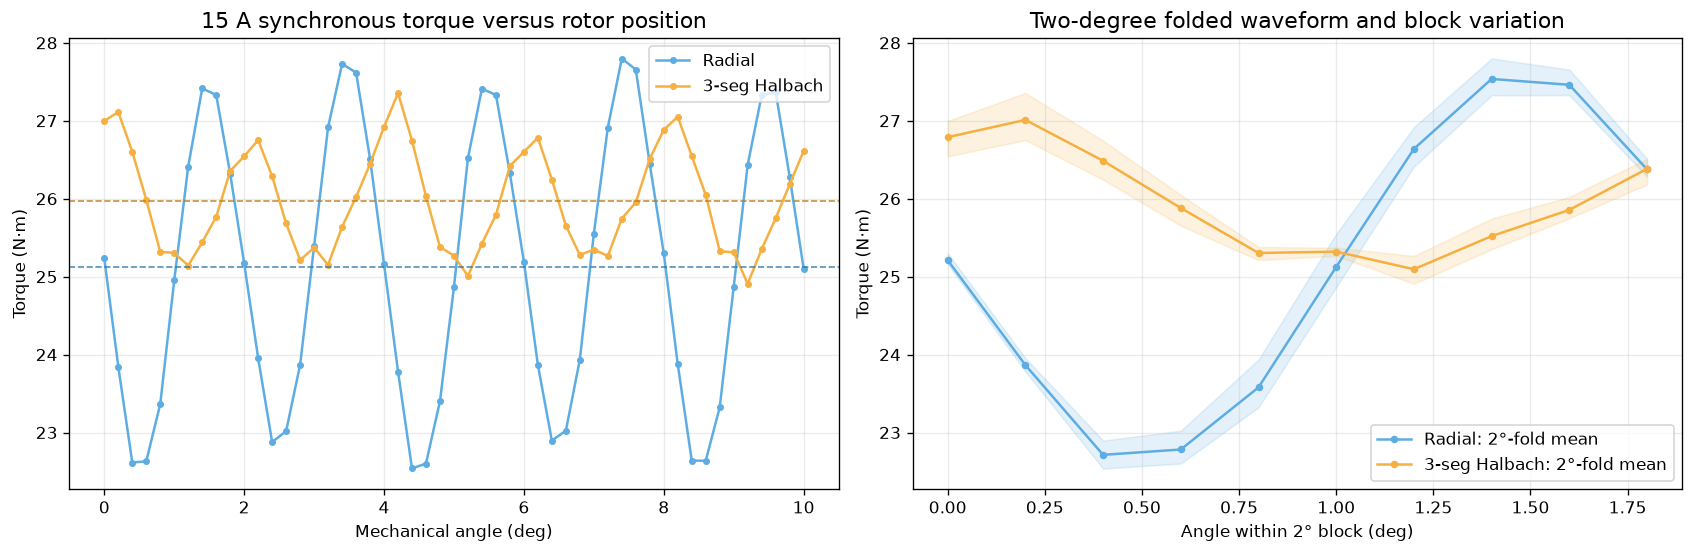

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(radial_pos.mechanical_angle_deg, radial_pos.torque_Nm, "o-", ms=3.2, label="Radial", color="#5dade2")
axes[0].plot(halbach_pos.mechanical_angle_deg, halbach_pos.torque_Nm, "o-", ms=3.2, label="3-seg Halbach", color="#f5b041")
axes[0].axhline(r.torque_Nm.mean(), color="#2874a6", ls="--", lw=1, alpha=.8)
axes[0].axhline(h.torque_Nm.mean(), color="#b9770e", ls="--", lw=1, alpha=.8)
axes[0].set(title="15 A synchronous torque versus rotor position", xlabel="Mechanical angle (deg)", ylabel="Torque (N·m)")
axes[0].grid(alpha=.25); axes[0].legend()

# Fold the five 2-degree blocks to expose the alternating pattern.
for name, frame, color in [("Radial", r, "#5dade2"), ("3-seg Halbach", h, "#f5b041")]:
    values = frame.torque_Nm.to_numpy().reshape(5, 10)
    phase = np.arange(10)*0.2
    axes[1].plot(phase, values.mean(axis=0), "o-", ms=3.5, color=color, label=f"{name}: 2°-fold mean")
    axes[1].fill_between(phase, values.min(axis=0), values.max(axis=0), color=color, alpha=.16)
axes[1].set(title="Two-degree folded waveform and block variation", xlabel="Angle within 2° block (deg)", ylabel="Torque (N·m)")
axes[1].grid(alpha=.25); axes[1].legend()
plt.show()

In [10]:
repeat_rows = []
for name, frame in [("Radial", r), ("3-seg Halbach", h)]:
    blocks = frame.torque_Nm.to_numpy().reshape(5, 10)
    for k in range(5):
        repeat_rows.append({"Design": name, "Block (deg)": f"{2*k:.0f}–{2*k+2:.0f}",
                            "Block mean (N·m)": blocks[k].mean(),
                            "Block p-p (N·m)": np.ptp(blocks[k]),
                            "RMSE vs first block (N·m)": np.sqrt(np.mean((blocks[k]-blocks[0])**2))})
repeat_table = pd.DataFrame(repeat_rows)
display(repeat_table.style.format({"Block mean (N·m)": "{:.3f}", "Block p-p (N·m)": "{:.3f}",
                                   "RMSE vs first block (N·m)": "{:.3f}"}))

mean_gain = h.torque_Nm.mean() - r.torque_Nm.mean()
mean_gain_pct = 100*(h.torque_Nm.mean()/r.torque_Nm.mean()-1)
ripple_reduction = 100*(1-np.ptp(h.torque_Nm)/np.ptp(r.torque_Nm))
print(f"Mean torque gain: {mean_gain:.3f} N·m ({mean_gain_pct:.2f}%)")
print(f"Peak-to-peak torque ripple reduction: {ripple_reduction:.2f}%")
print(f"Radial minimum at {r.loc[r.torque_Nm.idxmin(), 'mechanical_angle_deg']:.1f}°; "
      f"Halbach minimum at {h.loc[h.torque_Nm.idxmin(), 'mechanical_angle_deg']:.1f}°")

,Design,Block (deg),Block mean (N·m),Block p-p (N·m),RMSE vs first block (N·m)
0,Radial,0–2,25.012,4.801,0.000
1,Radial,2–4,25.306,4.852,0.340
2,Radial,4–6,24.994,4.873,0.060
3,Radial,6–8,25.327,4.902,0.379
4,Radial,8–10,25.006,4.732,0.051
5,3-seg Halbach,0–2,26.003,1.971,0.000
6,3-seg Halbach,2–4,25.911,1.600,0.256
7,3-seg Halbach,4–6,26.034,2.348,0.108
8,3-seg Halbach,6–8,25.938,1.517,0.259
9,3-seg Halbach,8–10,25.936,2.143,0.108


Mean torque gain: 0.836 N·m (3.33%)
Peak-to-peak torque ripple reduction: 53.48%
Radial minimum at 4.4°; Halbach minimum at 9.2°


### 5.1 위치 평균토크, 리플 및 반복주기

- 평균토크: 방사형 **25.129 N·m**, Halbach **25.964 N·m**
- Halbach 평균토크 이득: **+0.836 N·m (+3.33%)**
- 피크투피크 리플: 방사형 **5.261 N·m**, Halbach **2.447 N·m**
- 평균 대비 리플률: 방사형 **20.93%**, Halbach **9.42%**
- Halbach의 피크투피크 리플 크기는 방사형보다 **53.48% 감소**했다.
- 최소토크: 방사형 **22.538 N·m**, Halbach **24.909 N·m**으로 Halbach가 토크 저점을 크게 끌어올렸다.
- 최대토크는 방사형 **27.799 N·m**, Halbach **27.356 N·m**으로 비슷하며, Halbach의 주된 장점은 높은 피크보다 **평균 상승과 리플 억제**다.

단일 0° 위치에서는 Halbach 토크 이득이 약 7%였지만, 위치 평균에서는 **3.33%**로 낮아졌다. 따라서 단일 위치 결과만으로 평균토크 향상률을 판단하면 이 설계에서는 이득을 과대평가한다.

### 반복주기 판단

2° 블록들은 완전히 동일하지 않고 홀수/짝수 블록이 교대로 달라진다. 0–2°와 4–6°, 4–6°와 8–10° 파형이 더 가깝기 때문에 **약 4° 반복 성분**이 강하다. 이는 무부하 코깅의 최소 기하 반복각 2°와 달리, 부하 상태에서 권선 배치와 동기 전류 위상이 함께 작용하기 때문이다.

10° 데이터에는 약 4° 패턴이 2.5회 포함되어 평균과 리플의 설계 비교에는 충분한 경향을 제공한다. 다만 정확한 폐구간 평균을 확정하려면 다음 해석은 4°의 정수배인 **0–12°** 또는 전체 전기주기인 **0–24°**로 확장하는 것이 가장 깔끔하다.

### 5.2 15 A 위치 스윕의 설계 의미

- Halbach 평균토크는 Radial보다 **3.33% 높다**. 단일 0°에서 본 6–7%보다 작아 단점 해석이 이득을 과대평가했음을 확인했다.
- 피크투피크 토크리플은 **53.48% 감소**하고 평균 대비 리플률은 20.93%에서 9.42%로 낮아진다.
- Halbach의 주된 효과는 최대토크 상승보다 깊은 토크 저점의 완화다.
- 15 A 결과는 위치 평균의 중요성을 보여주는 대표 운전점이며 전체 전류 범위의 판단은 다음 0–50 A 통합 해석에서 수행한다.

## 6. 0–50 A 전류–위치 통합 분석

자속 비선형성과 위치 평균토크의 평탄화를 함께 보기 위해 두 설계를 다음 조건으로 해석했다.

- 전류: 0–20 A는 1 A 간격, 22–50 A는 2 A 간격(총 36전류)
- 기계각: 0–12°, 1° 간격(전류당 13점)
- 총 해석: 36전류 × 13위치 × 2설계 = **936점**
- 각 점의 공극 방사자속 $B_r$: 원주 1,440점
- 추가 저장: 공극 FFT, 외부 누설, 고정자 철심 표본의 mean/P95/P99/max와 고자속 표본 비율

12° 끝점은 반복성 확인용이다. 평균 계산에서는 0≤θ<12°의 12점을 사용한다.

### 평균토크의 0 A 편향 보정

1° 각도망은 평균토크 추세를 보기에는 충분하지만 코깅토크를 정확히 적분하기에는 거칠다. 실제 데이터에서 0 A 위치평균은 Radial -0.114 N·m, Halbach +0.044 N·m였다. 이 값은 물리적인 평균 구동토크가 아니라 각도 이산화 편향으로 보고, 전류별 평균토크에서 각 설계의 0 A 평균을 뺐다.

$$T_{\mathrm{corr}}(I)=\overline T(I)-\overline T(0)$$

토크리플 피크값은 1° 간격에서 누락될 수 있으므로 본 섹션에서는 전류별 대략적 추세로만 사용하고, 15 A의 정밀 리플 비교는 앞 절의 0.2° 결과를 우선한다.

In [11]:
map_paths = {
    "Radial": DATA / "nonlinear_current_angle_map_0to50A_radial" / "current_angle_map.csv",
    "3-seg Halbach": DATA / "nonlinear_current_angle_map_0to50A_halbach_3seg" / "current_angle_map.csv",
}

maps = {}
for name, path in map_paths.items():
    frame = pd.read_csv(path).sort_values(["current_peak_A", "mechanical_angle_deg"])
    assert len(frame) == 468
    assert frame[["current_peak_A", "mechanical_angle_deg"]].drop_duplicates().shape[0] == 468
    numeric_check = frame.select_dtypes(include=np.number).drop(columns=["torque_per_A_Nm_per_A"])
    assert numeric_check.notna().all().all()
    assert set(frame.current_peak_A) == set(list(range(21)) + list(range(22, 51, 2)))
    assert set(frame.mechanical_angle_deg) == set(range(13))
    maps[name] = frame[frame.mechanical_angle_deg < 12].copy()

def aggregate_map(frame):
    g = frame.groupby("current_peak_A")
    a = g.agg(
        torque_mean_raw=("torque_Nm", "mean"), torque_min=("torque_Nm", "min"),
        torque_max=("torque_Nm", "max"), gap_fundamental=("gap_fundamental_peak_T", "mean"),
        gap_thd=("gap_thd", "mean"), leakage_rms=("external_leakage_rms_T", "mean"),
        stator_B_mean=("stator_B_mean_T", "mean"), stator_B_p95=("stator_B_p95_T", "mean"),
        stator_B_p99=("stator_B_p99_T", "mean"), stator_B_max=("stator_B_max_T", "max"),
        stator_gt_1p8=("stator_fraction_gt_1p8", "mean"),
        stator_gt_2p0=("stator_fraction_gt_2p0", "mean"),
        rotor_yoke_B_p99=("rotor_yoke_B_p99_T", "mean"),
    )
    a["torque_mean"] = a.torque_mean_raw - a.loc[0, "torque_mean_raw"]
    a["torque_per_A"] = a.torque_mean / a.index.to_series().replace(0, np.nan)
    a["incremental_torque"] = np.gradient(a.torque_mean, a.index.to_numpy())
    a["torque_pp_coarse"] = a.torque_max - a.torque_min
    a["ripple_pct_coarse"] = 100*a.torque_pp_coarse/a.torque_mean.abs()
    return a

maps_agg = {name: aggregate_map(frame) for name, frame in maps.items()}
rad50, hal50 = maps_agg["Radial"], maps_agg["3-seg Halbach"]
print(f"Validated FEM points: {sum(len(x) for x in maps.values())} averaging points + 72 endpoint checks")
print(f"0 A angular bias: Radial {rad50.loc[0, 'torque_mean_raw']:+.4f} N·m, "
      f"Halbach {hal50.loc[0, 'torque_mean_raw']:+.4f} N·m")

Validated FEM points: 864 averaging points + 72 endpoint checks
0 A angular bias: Radial -0.1139 N·m, Halbach +0.0440 N·m


,Radial raw position mean (N·m),Halbach raw position mean (N·m),Radial mean torque (N·m),Halbach mean torque (N·m),Radial T/I (N·m/A),Halbach T/I (N·m/A),Radial dT/dI (N·m/A),Halbach dT/dI (N·m/A),Halbach torque gain (%)
current_peak_A,,,,,,,,,
1,1.628,1.806,1.741,1.762,1.741,1.762,1.738,1.760,1.182
5,8.525,8.830,8.639,8.786,1.728,1.757,1.708,1.751,1.702
10,16.956,17.535,17.070,17.491,1.707,1.749,1.666,1.727,2.466
11,18.618,19.258,18.732,19.214,1.703,1.747,1.659,1.718,2.570
12,20.273,20.971,20.387,20.927,1.699,1.744,1.651,1.708,2.649
15,25.188,26.040,25.302,25.996,1.687,1.733,1.624,1.670,2.746
20,33.158,34.236,33.272,34.192,1.664,1.710,1.560,1.610,2.765
30,48.172,49.863,48.286,49.819,1.610,1.661,1.452,1.515,3.176
40,62.101,64.335,62.215,64.291,1.555,1.607,1.327,1.376,3.336


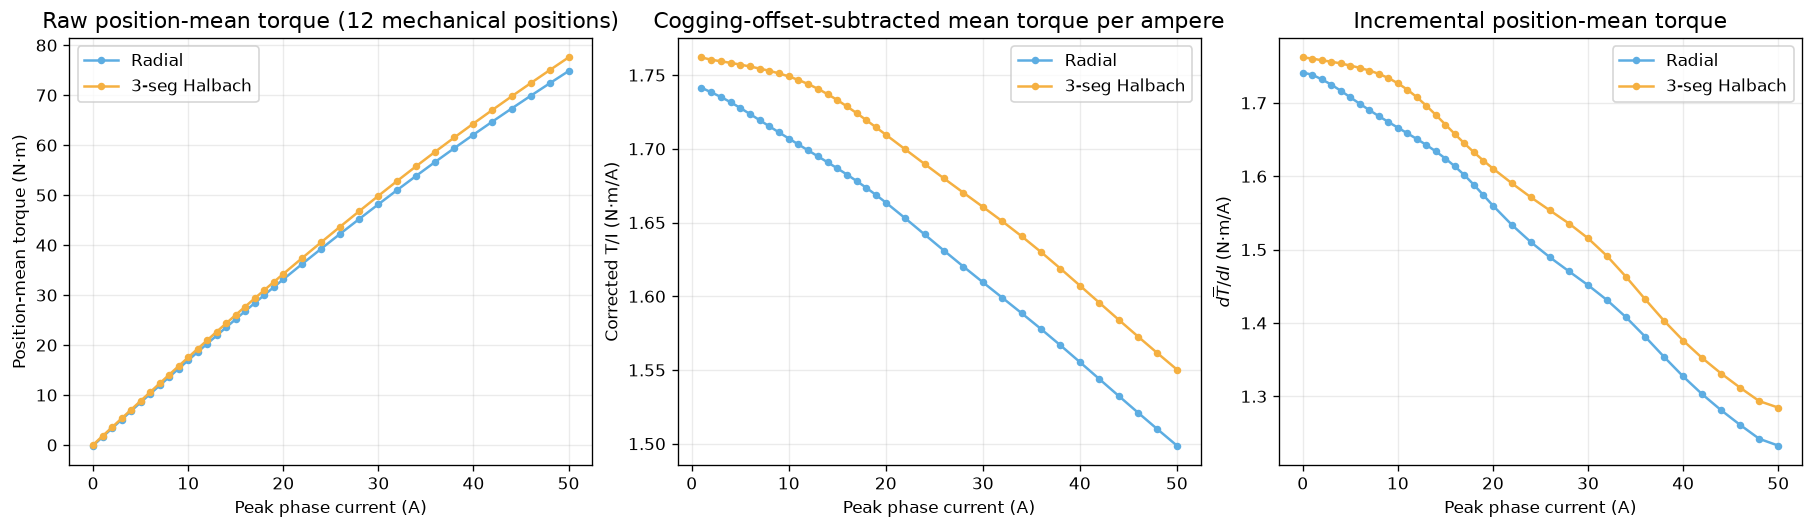

In [12]:
selected_currents = [1, 5, 10, 11, 12, 15, 20, 30, 40, 50]
summary_50A = pd.DataFrame({
    "Radial raw position mean (N·m)": rad50.loc[selected_currents, "torque_mean_raw"],
    "Halbach raw position mean (N·m)": hal50.loc[selected_currents, "torque_mean_raw"],
    "Radial mean torque (N·m)": rad50.loc[selected_currents, "torque_mean"],
    "Halbach mean torque (N·m)": hal50.loc[selected_currents, "torque_mean"],
    "Radial T/I (N·m/A)": rad50.loc[selected_currents, "torque_per_A"],
    "Halbach T/I (N·m/A)": hal50.loc[selected_currents, "torque_per_A"],
    "Radial dT/dI (N·m/A)": rad50.loc[selected_currents, "incremental_torque"],
    "Halbach dT/dI (N·m/A)": hal50.loc[selected_currents, "incremental_torque"],
})
summary_50A["Halbach torque gain (%)"] = 100*(summary_50A["Halbach mean torque (N·m)"] /
                                                summary_50A["Radial mean torque (N·m)"] - 1)
display(summary_50A.style.format("{:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
for name, a, color in [("Radial", rad50, "#5dade2"), ("3-seg Halbach", hal50, "#f5b041")]:
    axes[0].plot(a.index, a.torque_mean_raw, "o-", ms=3.5, label=name, color=color)
    axes[1].plot(a.index[1:], a.torque_per_A.iloc[1:], "o-", ms=3.5, label=name, color=color)
    axes[2].plot(a.index, a.incremental_torque, "o-", ms=3.5, label=name, color=color)
axes[0].set(title="Raw position-mean torque (12 mechanical positions)", xlabel="Peak phase current (A)", ylabel="Position-mean torque (N·m)")
axes[1].set(title="Cogging-offset-subtracted mean torque per ampere", xlabel="Peak phase current (A)", ylabel="Corrected T/I (N·m/A)")
axes[2].set(title="Incremental position-mean torque", xlabel="Peak phase current (A)", ylabel=r"$d\overline{T}/dI$ (N·m/A)")
for ax in axes: ax.grid(alpha=.25); ax.legend()
plt.show()

### 6.1 평균토크 평탄화

- Radial 증분토크는 저전류 기준 약 1.724 N·m/A에서 50 A의 **1.233 N·m/A**로 감소했다.
- Halbach 증분토크는 저전류 기준 약 1.756 N·m/A에서 50 A의 **1.285 N·m/A**로 감소했다.
- 저전류 기울기의 95% 아래로 내려가는 첫 전류는 Radial 약 **14 A**, Halbach 약 **16 A**다.
- 90% 아래는 Radial 약 **22 A**, Halbach 약 **24 A**, 80% 아래는 두 설계 모두 약 **38 A**다.
- 1→50 A의 $T/I$ 감소율은 Radial 약 **13.9%**, Halbach 약 **12.0%**다.

따라서 토크 자체는 50 A까지 계속 증가하지만, 추가 전류당 토크가 약 27–29% 줄어드는 명확한 평탄화가 나타난다. Halbach는 전 구간에서 더 높은 평균토크와 증분토크를 유지하며, 보정 평균토크 이득은 15 A의 **2.75%**에서 50 A의 **3.44%**로 증가한다.

11 A에서 특별한 급격한 꺾임은 위치 평균과 P99에서는 재현되지 않았다. 이전 한 위치의 최대 샘플 기울기 변화는 국부 최대 위치 전환 또는 단일 위치 효과일 가능성이 크다.

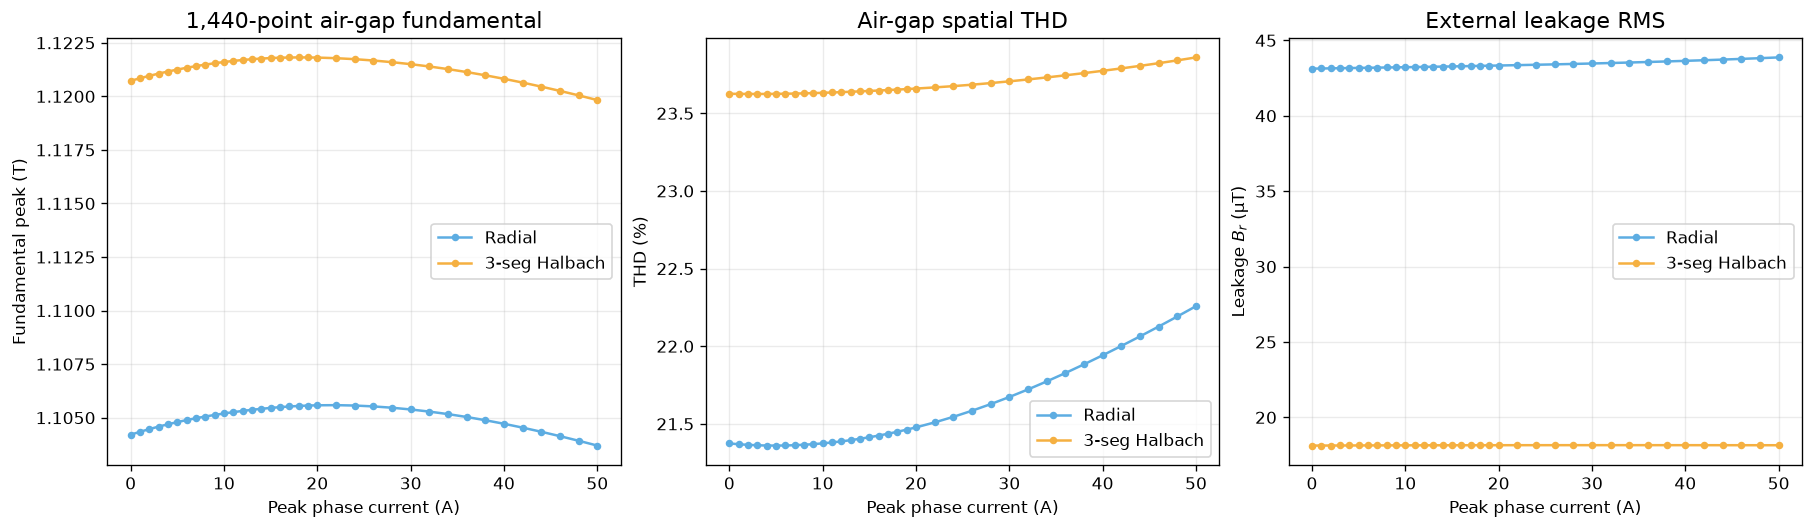

,Radial 0 A,Radial 50 A,Halbach 0 A,Halbach 50 A
Air-gap fundamental peak (T),1.1042,1.1037,1.1207,1.1198
Air-gap THD (%),21.3740,22.2579,23.6257,23.8599
External leakage RMS (µT),43.1240,43.8692,18.1283,18.1514


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
for name, a, color in [("Radial", rad50, "#5dade2"), ("3-seg Halbach", hal50, "#f5b041")]:
    axes[0].plot(a.index, a.gap_fundamental, "o-", ms=3.5, label=name, color=color)
    axes[1].plot(a.index, 100*a.gap_thd, "o-", ms=3.5, label=name, color=color)
    axes[2].plot(a.index, 1e6*a.leakage_rms, "o-", ms=3.5, label=name, color=color)
axes[0].set(title="1,440-point air-gap fundamental", xlabel="Peak phase current (A)", ylabel="Fundamental peak (T)")
axes[1].set(title="Air-gap spatial THD", xlabel="Peak phase current (A)", ylabel="THD (%)")
axes[2].set(title="External leakage RMS", xlabel="Peak phase current (A)", ylabel="Leakage $B_r$ (µT)")
for ax in axes: ax.grid(alpha=.25); ax.legend()
plt.show()

flux_summary = pd.DataFrame({
    "Radial 0 A": [rad50.loc[0,"gap_fundamental"], 100*rad50.loc[0,"gap_thd"], 1e6*rad50.loc[0,"leakage_rms"]],
    "Radial 50 A": [rad50.loc[50,"gap_fundamental"], 100*rad50.loc[50,"gap_thd"], 1e6*rad50.loc[50,"leakage_rms"]],
    "Halbach 0 A": [hal50.loc[0,"gap_fundamental"], 100*hal50.loc[0,"gap_thd"], 1e6*hal50.loc[0,"leakage_rms"]],
    "Halbach 50 A": [hal50.loc[50,"gap_fundamental"], 100*hal50.loc[50,"gap_thd"], 1e6*hal50.loc[50,"leakage_rms"]],
}, index=["Air-gap fundamental peak (T)", "Air-gap THD (%)", "External leakage RMS (µT)"])
display(flux_summary.style.format("{:.4f}"))

### 6.2 공극 기본파와 외부 누설자속

- Halbach 공극 기본파는 전류 전 구간에서 Radial보다 약 **1.46–1.49% 높다**.
- 0→50 A에서 기본파 크기 변화는 Radial **-0.046%**, Halbach **-0.080%**에 불과하다.
- q축 전류가 증가해도 영구자석이 지배하는 공극 기본파 크기는 거의 유지된다.
- 공극 THD는 0→50 A에서 Radial 약 21.37→22.26%, Halbach 약 23.63→23.86%로 증가한다.
- Halbach 외부 누설 RMS는 전 구간에서 Radial보다 약 **58% 낮다**.

따라서 토크 평탄화는 공극 기본파 자체가 크게 붕괴해서 생긴 것이 아니다. 전류 증가에 따른 국부 철심 포화, 전기자 반작용과 자속 경로 재분배가 토크 증가 효율을 낮추는 것으로 해석된다.

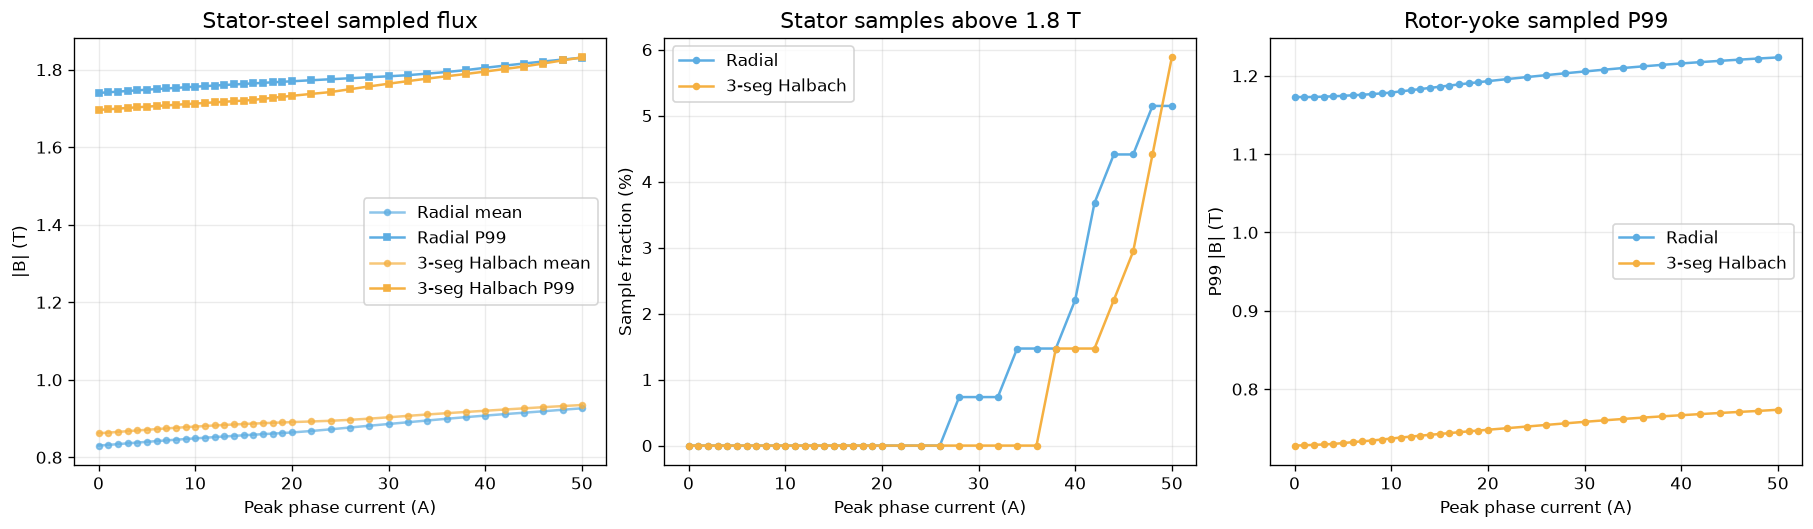

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
for name, a, color in [("Radial", rad50, "#5dade2"), ("3-seg Halbach", hal50, "#f5b041")]:
    axes[0].plot(a.index, a.stator_B_mean, "o-", ms=3.5, label=f"{name} mean", color=color, alpha=.7)
    axes[0].plot(a.index, a.stator_B_p99, "s-", ms=3.2, label=f"{name} P99", color=color)
    axes[1].plot(a.index, 100*a.stator_gt_1p8, "o-", ms=3.5, label=name, color=color)
    axes[2].plot(a.index, a.rotor_yoke_B_p99, "o-", ms=3.5, label=name, color=color)
axes[0].set(title="Stator-steel sampled flux", xlabel="Peak phase current (A)", ylabel="|B| (T)")
axes[1].set(title="Stator samples above 1.8 T", xlabel="Peak phase current (A)", ylabel="Sample fraction (%)")
axes[2].set(title="Rotor-yoke sampled P99", xlabel="Peak phase current (A)", ylabel="P99 |B| (T)")
for ax in axes: ax.grid(alpha=.25); ax.legend()
plt.show()

### 6.3 고정자 및 회전자 철심 포화

- 고정자 P99는 0→50 A에서 Radial **1.740→1.831 T**, Halbach **1.696→1.832 T**로 증가한다.
- 1.8 T 초과 고정자 표본은 Radial에서 약 **28 A**, Halbach에서 약 **38 A**부터 나타난다.
- 50 A의 1.8 T 초과 비율은 Radial **5.15%**, Halbach **5.88%**다.
- 두 설계 모두 50 A까지 2.0 T 초과 표본은 없었다.
- 회전자 요크 P99는 50 A에서 Radial 약 **1.223 T**, Halbach 약 **0.774 T**다. Halbach의 회전자 요크 부담은 고전류에서도 훨씬 낮다.

Halbach는 중간 전류에서 고정자 고자속 영역의 출현을 약 10 A 늦추지만, 50 A에서는 고정자 P99가 Radial과 거의 같아진다. 즉 고전류 한계는 회전자 요크보다 고정자 철심에서 결정될 가능성이 높다.

### 6.4 0–50 A 통합 해석 결과

1. 두 설계 모두 50 A까지 평균토크는 증가하지만 증분토크는 저전류 대비 약 27–29% 감소한다.
2. 포화는 특정 전류에서 갑자기 발생하기보다 Radial 약 14 A, Halbach 약 16 A부터 완만하게 나타난다.
3. Halbach는 공극 기본파가 약 1.5% 높고 외부 누설이 약 58% 낮다.
4. Halbach 평균토크 이득은 약 1–3.4%이며 50 A에서 약 +2.58 N·m다.
5. 50 A에서는 고정자 P99가 두 설계 모두 약 1.83 T로 접근해 추가 전류의 한계가 회전자보다 고정자·열·인버터 조건에서 결정될 가능성이 크다.

동일 치수의 토크 이득만으로는 Halbach의 추가 공정비를 정당화하기 어렵다. 따라서 다음 절에서는 낮은 회전자 요크 자속을 백아이언·외경·관성 축소로 전환할 수 있는지 검토한다.

## 7. 백아이언 50% 축소 검증

Halbach의 낮은 회전자 요크 자속을 실제 경량화에 활용할 수 있는지 확인하기 위해 회전자 백아이언을 **5.0 mm에서 2.5 mm로 절반 축소**했다.

| 항목 | 기준 설계 | 축소 설계 |
|---|---:|---:|
| 자석 외측 반경 | 70.0 mm | 70.0 mm |
| 회전자 외반경 | 75.0 mm | 72.5 mm |
| 백아이언 두께 | 5.0 mm | 2.5 mm |
| 회전자 외경 | 150 mm | 145 mm |
| 백아이언 단면적 변화 | 기준 | 약 50.9% 감소 |

비교 조건은 50 A, 기계각 0–12°, 1° 간격이며 평균 계산에는 0≤θ<12°의 12점을 사용했다. 기계각 0° 해답은 별도 `.fem/.ans`로 보존했다.

### 7.1 50 A, 기계각 0° 자속밀도 분포

**Radial, 2.5 mm 백아이언**

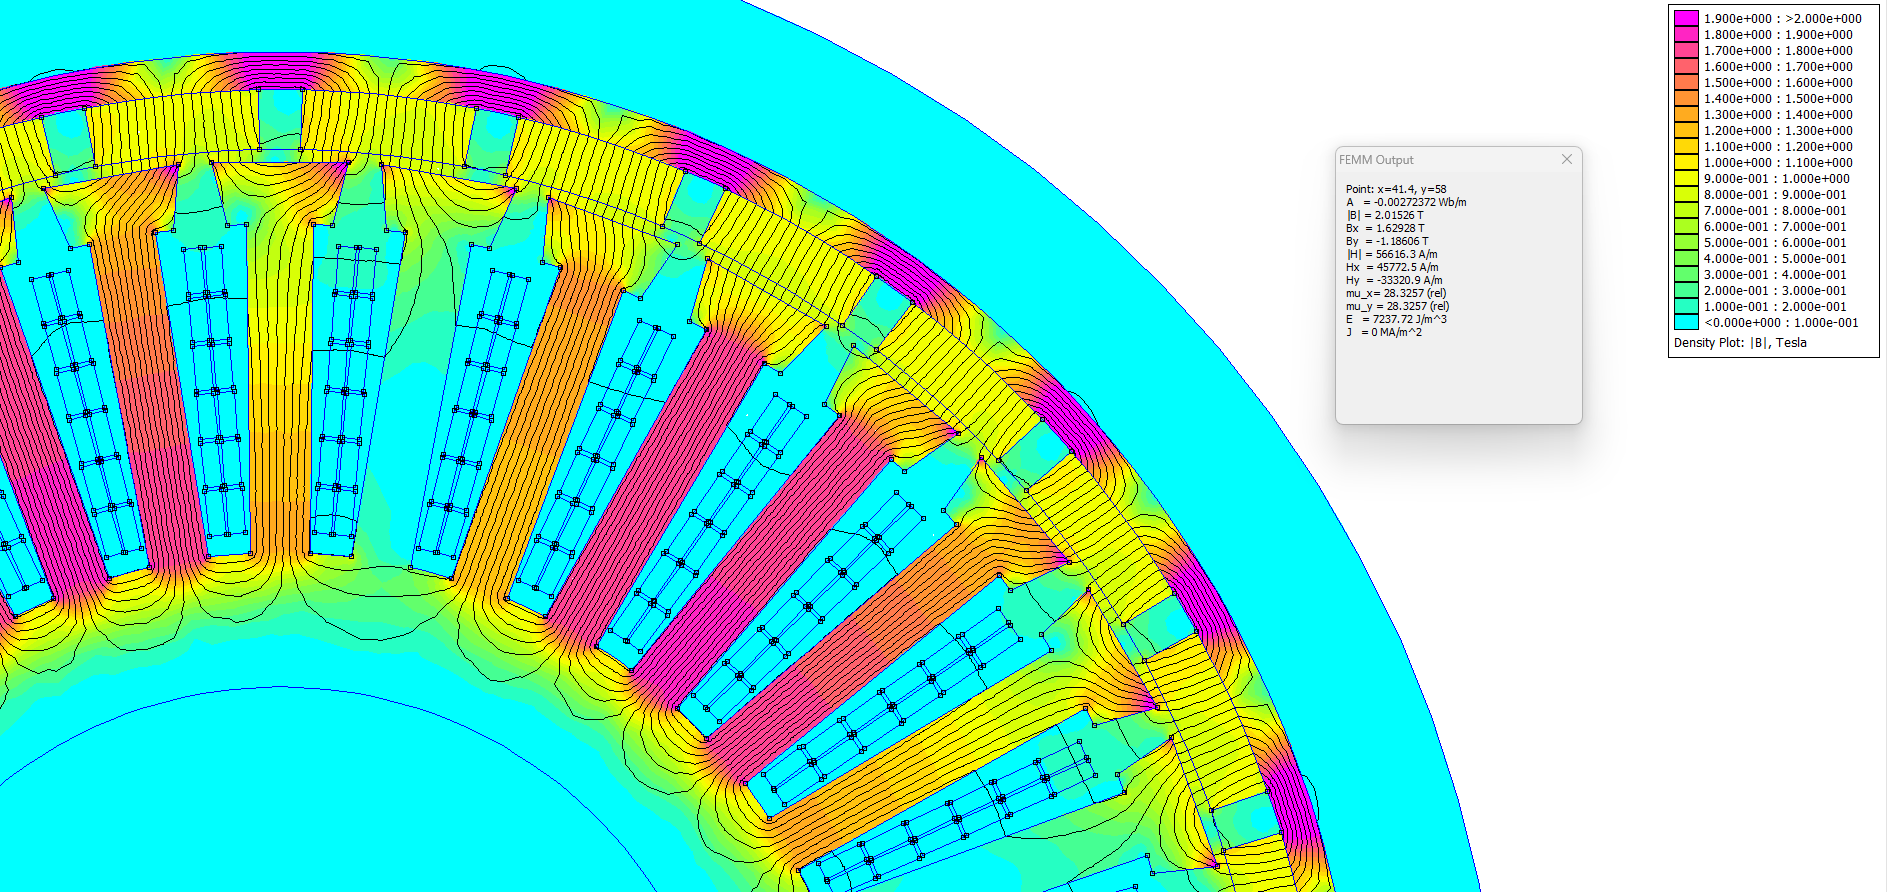

**3분할 Halbach, 2.5 mm 백아이언**

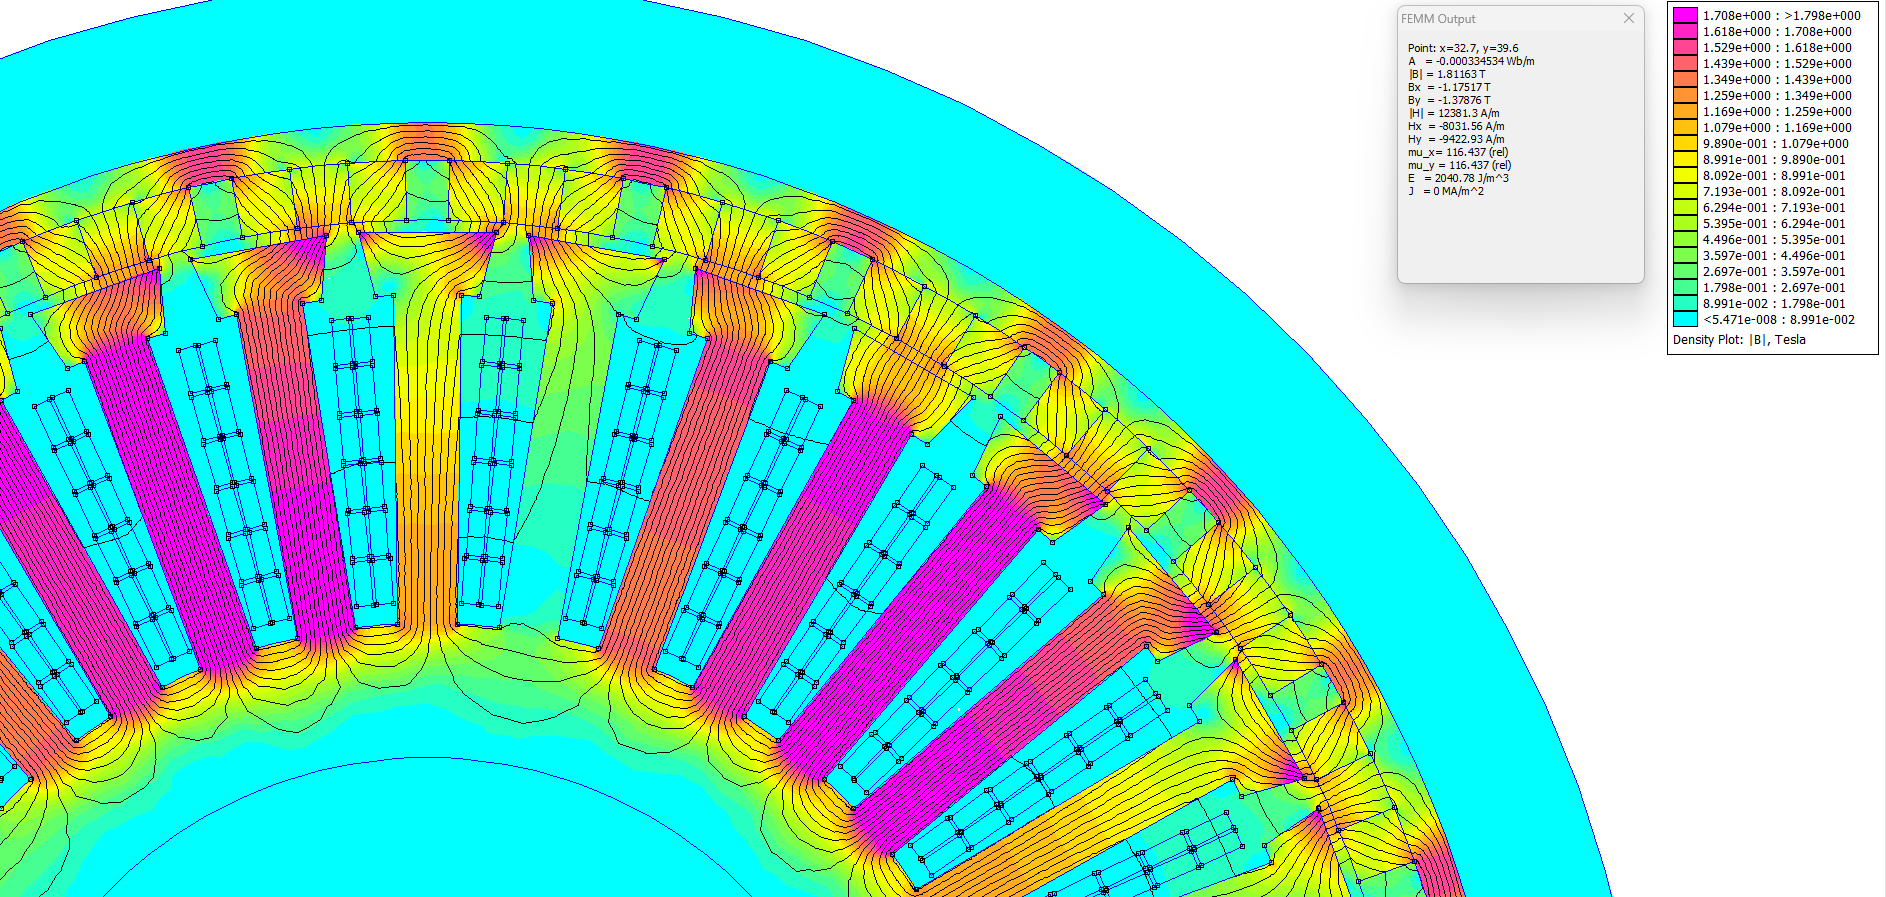

> 캡처의 컬러바 범위가 서로 다르다. Radial 상한은 2.0 T, Halbach 상한은 약 1.80 T이므로 색상을 직접 정량 비교하지 않고 아래의 동일 좌표 샘플 통계를 기준으로 판단한다.

,5 mm mean torque (N·m),2.5 mm mean torque (N·m),Torque change (%),5 mm air-gap fundamental (T),2.5 mm air-gap fundamental (T),Gap fundamental change (%),5 mm rotor-yoke P99 (T),2.5 mm rotor-yoke P99 (T),2.5 mm rotor-yoke max (T)
Design,,,,,,,,,
Radial,74.823,72.948,-2.506,1.104,1.062,-3.811,1.223,2.078,2.091
3-seg Halbach,77.560,77.523,-0.048,1.120,1.121,0.067,0.774,1.594,1.596


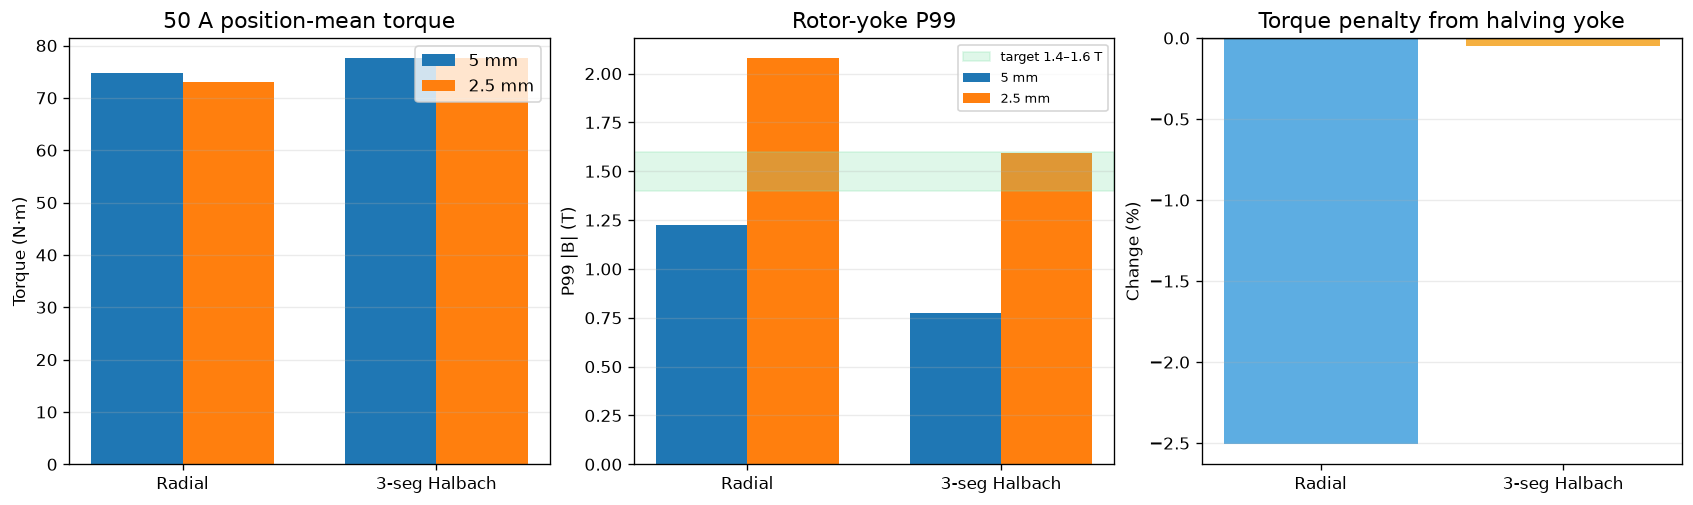

In [15]:
half_yoke_paths = {
    "Radial": DATA / "half_rotor_yoke_2p5mm" / "radial" / "half_yoke_50A_angle_map.csv",
    "3-seg Halbach": DATA / "half_rotor_yoke_2p5mm" / "halbach_3seg" / "half_yoke_50A_angle_map.csv",
}

half_yoke = {}
for name, path in half_yoke_paths.items():
    frame = pd.read_csv(path).sort_values("mechanical_angle_deg")
    assert len(frame) == 13 and set(frame.mechanical_angle_deg) == set(range(13))
    half_yoke[name] = frame[frame.mechanical_angle_deg < 12].copy()

base_50 = {
    "Radial": maps["Radial"][maps["Radial"].current_peak_A == 50],
    "3-seg Halbach": maps["3-seg Halbach"][maps["3-seg Halbach"].current_peak_A == 50],
}

rows = []
for name in ["Radial", "3-seg Halbach"]:
    old, new = base_50[name], half_yoke[name]
    rows.append({
        "Design": name,
        "5 mm mean torque (N·m)": old.torque_Nm.mean(),
        "2.5 mm mean torque (N·m)": new.torque_Nm.mean(),
        "Torque change (%)": 100*(new.torque_Nm.mean()/old.torque_Nm.mean()-1),
        "5 mm air-gap fundamental (T)": old.gap_fundamental_peak_T.mean(),
        "2.5 mm air-gap fundamental (T)": new.gap_fundamental_peak_T.mean(),
        "Gap fundamental change (%)": 100*(new.gap_fundamental_peak_T.mean()/old.gap_fundamental_peak_T.mean()-1),
        "5 mm rotor-yoke P99 (T)": old.rotor_yoke_B_p99_T.mean(),
        "2.5 mm rotor-yoke P99 (T)": new.rotor_yoke_B_p99_T.mean(),
        "2.5 mm rotor-yoke max (T)": new.rotor_yoke_B_max_T.mean(),
    })
half_yoke_summary = pd.DataFrame(rows).set_index("Design")
display(half_yoke_summary.style.format("{:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1), constrained_layout=True)
x = np.arange(2); labels = ["Radial", "3-seg Halbach"]
axes[0].bar(x-.18, half_yoke_summary["5 mm mean torque (N·m)"], .36, label="5 mm")
axes[0].bar(x+.18, half_yoke_summary["2.5 mm mean torque (N·m)"], .36, label="2.5 mm")
axes[0].set(title="50 A position-mean torque", ylabel="Torque (N·m)", xticks=x, xticklabels=labels); axes[0].legend()
axes[1].bar(x-.18, half_yoke_summary["5 mm rotor-yoke P99 (T)"], .36, label="5 mm")
axes[1].bar(x+.18, half_yoke_summary["2.5 mm rotor-yoke P99 (T)"], .36, label="2.5 mm")
axes[1].axhspan(1.4, 1.6, color="#82e0aa", alpha=.25, label="target 1.4–1.6 T")
axes[1].set(title="Rotor-yoke P99", ylabel="P99 |B| (T)", xticks=x, xticklabels=labels); axes[1].legend(fontsize=8)
axes[2].bar(labels, half_yoke_summary["Torque change (%)"], color=["#5dade2", "#f5b041"])
axes[2].axhline(0, color="black", lw=.8)
axes[2].set(title="Torque penalty from halving yoke", ylabel="Change (%)")
for ax in axes: ax.grid(axis="y", alpha=.25)
plt.show()

### 7.2 5.0 mm와 2.5 mm 비교

- Radial은 2.5 mm에서 회전자 요크 P99가 **1.223→2.078 T**, max가 약 **2.091 T**까지 올라가 강하게 포화됐다.
- Radial 공극 기본파는 **3.81% 감소**, 50 A 위치 평균토크는 **2.51% 감소**했다.
- Halbach는 2.5 mm에서 회전자 요크 P99 약 **1.594 T**, max 약 **1.596 T**로 권장 공격 설계 범위 안에 머문다.
- Halbach 공극 기본파 변화는 **+0.07%**, 위치 평균토크 변화는 **-0.05%**로 사실상 성능을 유지한다.
- 2.5 mm Halbach 평균토크는 5 mm Radial보다도 약 **3.61% 높다**.
- 같은 2.5 mm 조건에서는 Halbach 평균토크가 Radial보다 약 **6.27% 높다**.

이 결과는 동일 치수 교체에서 작았던 Halbach의 토크 이득을 **회전자 구조 경량화와 외경 축소**로 전환할 수 있음을 보여준다. Radial은 같은 축소에서 요크가 2 T 이상 포화되지만 Halbach는 1.6 T 수준으로 유지된다.

### 7.3 50% 축소 검증에서 얻은 설계 의미

- 2.5 mm Radial은 회전자 요크 P99가 약 2.08 T로 상승하고 평균토크가 2.51% 감소한다.
- 2.5 mm Halbach는 P99 약 1.59 T 수준에서 평균토크 변화가 -0.05%에 불과하다.
- 동일한 2.5 mm에서 Halbach 평균토크는 Radial보다 약 6.27% 높다.
- 이 단일 축소 실험은 Halbach의 낮은 요크 자속을 경량화로 전환할 수 있음을 보여주지만 2.5 mm를 곧바로 최종 치수로 확정하지는 않는다.

따라서 다음 절에서 1.50–5.00 mm 전 두께 곡선과 경계 후보의 전체 위치 결과를 함께 비교한다.

## 8. 백아이언 전체 두께 스윕과 경계안 검증

50 A 정자계 조건에서 회전자 백아이언을 1.50–5.00 mm(0.25 mm 간격)로 1차 스크리닝한 뒤, 경계 후보를 한 전기주기인 기계각 0–12°에서 1° 간격으로 재해석했다. 12°는 0°와 같은 주기의 끝점이므로 평균 토크와 리플 계산에서는 0–11°의 12개 독립 위치만 사용했다.

결과를 특정 한계값으로 미리 합격/탈락시키지 않고 전 두께 곡선을 제시한다. P99 1.6 T와 max 1.7 T는 재료·열·제조 조건이 확정되기 전의 **설계 참고선**으로만 표시하며, 최종 한계는 곡선의 무릎점과 허용 손실을 보고 선택한다.

In [16]:
validation_paths = {
    "Radial": DATA / "rotor_yoke_thickness_screen_50A/radial/full_angle_validation/candidate_angle_map.csv",
    "3-seg Halbach": DATA / "rotor_yoke_thickness_screen_50A/halbach_3seg/full_angle_validation/candidate_angle_map.csv",
}

validation = {}
summary_rows = []
screen_paths = {
    "Radial": DATA / "rotor_yoke_thickness_screen_50A/radial/thickness_screen.csv",
    "3-seg Halbach": DATA / "rotor_yoke_thickness_screen_50A/halbach_3seg/thickness_screen.csv",
}
screens = {name: pd.read_csv(path).sort_values("yoke_thickness_mm") for name, path in screen_paths.items()}
for design, path in validation_paths.items():
    raw = pd.read_csv(path).sort_values(["yoke_thickness_mm", "mechanical_angle_deg"])
    assert len(raw) == 39 and not raw.isna().any().any()
    independent = raw[(raw.mechanical_angle_deg >= 0) & (raw.mechanical_angle_deg < 12)].copy()
    assert independent.groupby("yoke_thickness_mm").size().eq(12).all()
    validation[design] = independent
    for thickness, g in independent.groupby("yoke_thickness_mm"):
        mean_t = g.torque_Nm.mean()
        summary_rows.append({
            "Design": design,
            "Yoke thickness (mm)": thickness,
            "Mean torque (N·m)": mean_t,
            "Torque min (N·m)": g.torque_Nm.min(),
            "Torque max (N·m)": g.torque_Nm.max(),
            "Torque ripple pk-pk/mean (%)": 100*(g.torque_Nm.max()-g.torque_Nm.min())/mean_t,
            "Gap fundamental mean (T)": g.gap_fundamental_peak_T.mean(),
            "Worst yoke P99 (T)": g.rotor_yoke_B_p99_T.max(),
            "Worst yoke max (T)": g.rotor_yoke_B_max_T.max(),
        })

yoke_validation_summary = pd.DataFrame(summary_rows)
display(yoke_validation_summary.set_index(["Design", "Yoke thickness (mm)"]).style.format({
    "Mean torque (N·m)":"{:.3f}", "Torque min (N·m)":"{:.3f}", "Torque max (N·m)":"{:.3f}",
    "Torque ripple pk-pk/mean (%)":"{:.3f}", "Gap fundamental mean (T)":"{:.4f}",
    "Worst yoke P99 (T)":"{:.4f}", "Worst yoke max (T)":"{:.4f}",
}))

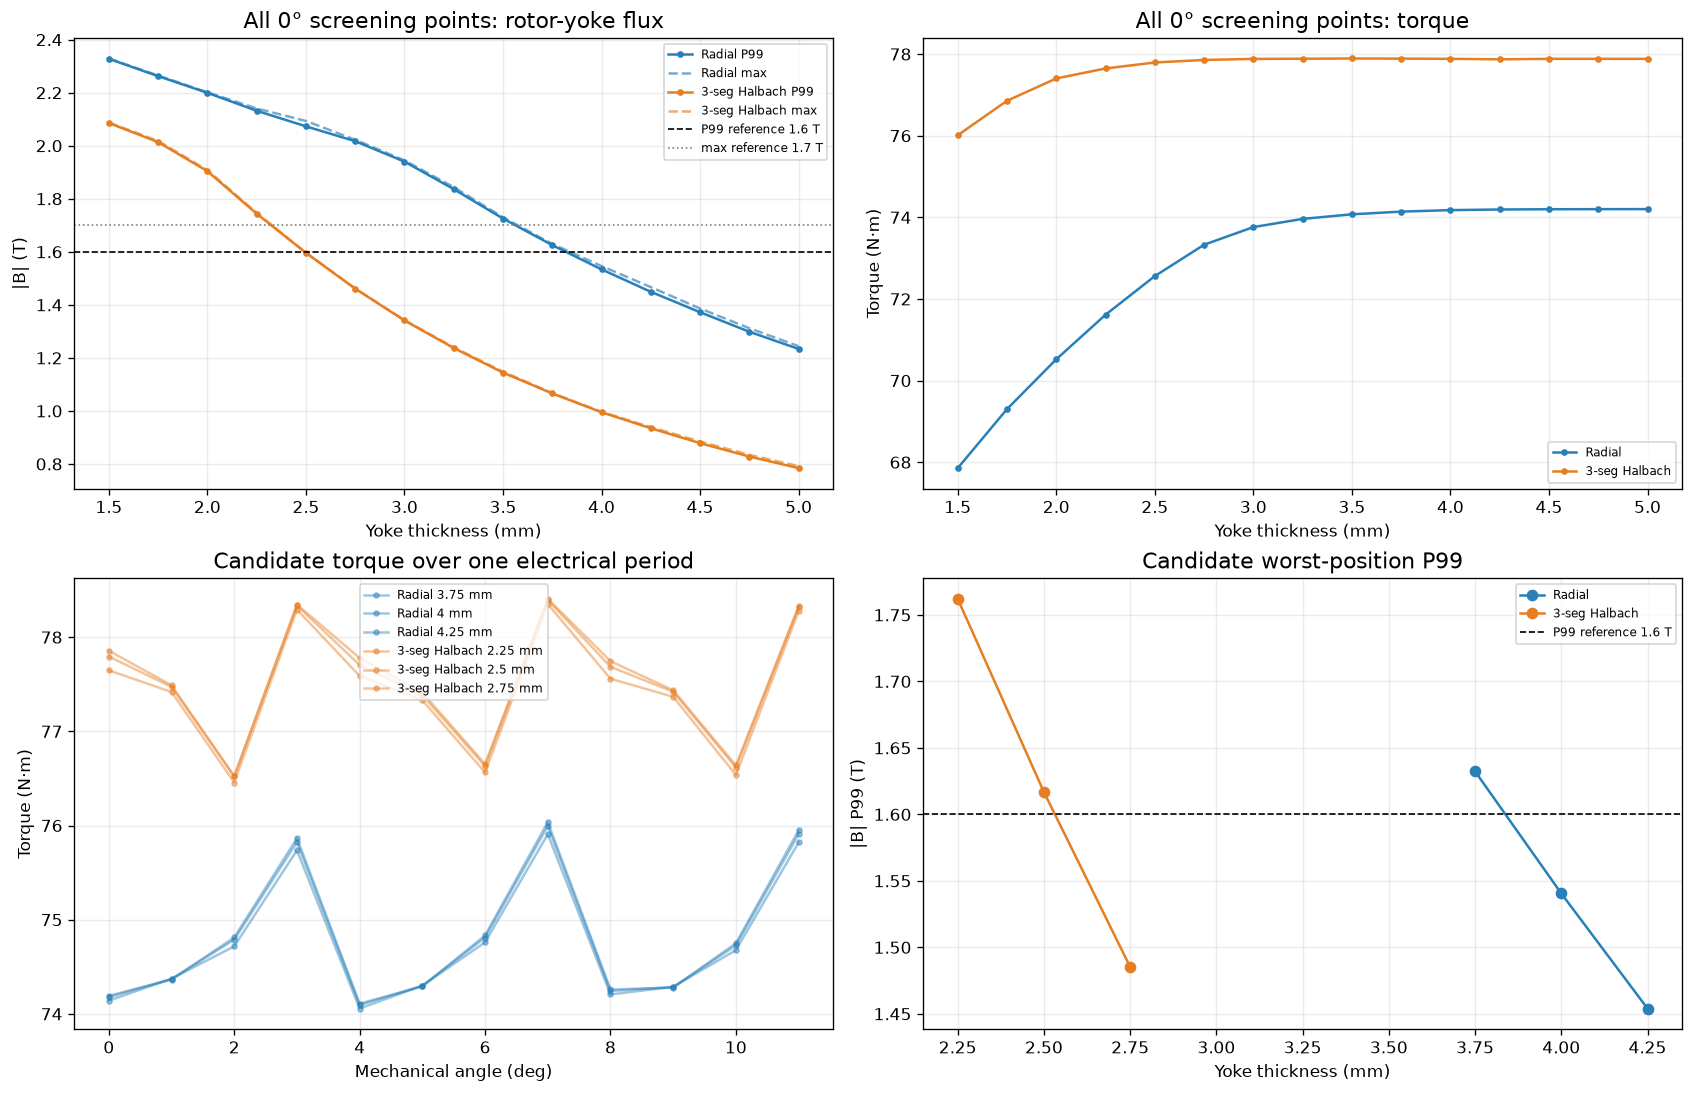

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
colors = {"Radial":"#2980b9", "3-seg Halbach":"#e67e22"}
for design, s in screens.items():
    color = colors[design]
    axes[0,0].plot(s.yoke_thickness_mm, s.rotor_yoke_B_p99_T, "o-", ms=3, color=color, label=f"{design} P99")
    axes[0,0].plot(s.yoke_thickness_mm, s.rotor_yoke_B_max_T, "--", color=color, alpha=.65, label=f"{design} max")
    axes[0,1].plot(s.yoke_thickness_mm, s.torque_Nm, "o-", ms=3, color=color, label=design)
for design, frame in validation.items():
    color = colors[design]
    for thickness, g in frame.groupby("yoke_thickness_mm"):
        axes[1,0].plot(g.mechanical_angle_deg, g.torque_Nm, "o-", ms=3, color=color,
                       alpha=.45 + .12*(thickness-g.yoke_thickness_mm.min()), label=f"{design} {thickness:g} mm")
    s = yoke_validation_summary[yoke_validation_summary.Design == design]
    axes[1,1].plot(s["Yoke thickness (mm)"], s["Worst yoke P99 (T)"], "o-", color=color, label=design)
axes[0,0].axhline(1.6, color="black", ls="--", lw=1, label="P99 reference 1.6 T")
axes[0,0].axhline(1.7, color="gray", ls=":", lw=1, label="max reference 1.7 T")
axes[0,0].set(title="All 0° screening points: rotor-yoke flux", xlabel="Yoke thickness (mm)", ylabel="|B| (T)")
axes[0,1].set(title="All 0° screening points: torque", xlabel="Yoke thickness (mm)", ylabel="Torque (N·m)")
axes[1,0].set(title="Candidate torque over one electrical period", xlabel="Mechanical angle (deg)", ylabel="Torque (N·m)")
axes[1,1].axhline(1.6, color="black", ls="--", lw=1, label="P99 reference 1.6 T")
axes[1,1].set(title="Candidate worst-position P99", xlabel="Yoke thickness (mm)", ylabel="|B| P99 (T)")
for ax in axes.flat:
    ax.grid(alpha=.25); ax.legend(fontsize=7)
plt.show()

### 8.1 곡선에서 제안하는 설계 구간

- 모든 1.50–5.00 mm 결과를 보면 두께가 얇아질수록 P99가 연속적으로 증가하며, 물리적으로 갑자기 불가능해지는 단일 절단점은 없다.
- 위치 검증값은 Radial 3.75/4.00/4.25 mm에서 각각 1.632/1.541/1.454 T, Halbach 2.25/2.50/2.75 mm에서 각각 1.762/1.617/1.485 T다.
- 따라서 **보수적인 참고선 P99≈1.6 T**를 채택하면 제안점은 Radial 약 4.0 mm, Halbach 약 2.6–2.75 mm다. 다만 1.6 T가 확정 재료 한계는 아니므로 2.50 mm Halbach와 3.75 mm Radial도 탈락안이 아니라 경량화와 포화 여유를 교환하는 경계안으로 유지한다.
- 실제 리미트는 사용 강판의 B–H 곡선, 철손·온도, 최대전류 지속시간 및 구조 안전율을 결합해 정해야 한다. 이 데이터만으로는 **Radial 3.75–4.00 mm, Halbach 2.50–2.75 mm**를 최종 검토 범위로 제시하는 것이 타당하다.
- 같은 보수점끼리 비교하면 Halbach는 평균 토크가 약 3.7% 높고 더 얇은 백아이언을 허용한다. Halbach의 설계 가치는 최고 토크 하나가 아니라 포화 여유와 경량화 선택 폭에 있다.

결론적으로 그래프에는 어느 점도 제거하지 않았으며, 1.6/1.7 T 선은 선택을 돕는 참고선일 뿐 합격·불합격 판정선이 아니다.

### 8.2 백아이언 경량화와 관성 효과

전자기적 두께 후보가 실제 회전자 경량화에 주는 효과를 계산했다. 강판 밀도 7,650 kg/m³, 적층길이 150 mm, 백아이언 내반경 70 mm의 원통형 링으로 가정했다. 질량과 극관성모멘트는 **백아이언만의 값**이며 자석, 슬리브, 허브와 축은 포함하지 않는다.

$$m=\rho\pi L(R_o^2-R_i^2),\qquad J_p=\frac{1}{2}m(R_o^2+R_i^2)$$

정격 및 최대 RPM은 이 정자계 결과만으로 결정하지 않는다. 후속 단계에서 역기전력·인버터 전압 제한, 철손·열 및 최대속도 원심응력을 결합해 산정해야 한다.

,Back-iron thickness (mm),Rotor OD (mm),Back-iron mass (kg),Back-iron polar inertia (kg·m²),Mean torque (N·m),Torque/back-iron mass (N·m/kg),Mass reduction vs Radial 5 mm (%),Inertia reduction vs Radial 5 mm (%),Torque change vs Radial 5 mm (%)
Candidate,,,,,,,,,
Radial 5.00 mm,5.000,150.000,2.614,0.014,74.823,28.628,0.000,0.000,0.000
Radial 3.75 mm,3.750,147.500,1.943,0.010,74.749,38.465,25.647,26.960,-0.099
Radial 4.00 mm,4.000,148.000,2.076,0.011,74.793,36.019,20.552,21.676,-0.039
Halbach 2.50 mm,2.500,145.000,1.284,0.007,77.523,60.363,50.862,52.584,3.609
Halbach 2.75 mm,2.750,145.500,1.415,0.007,77.551,54.800,45.853,47.564,3.647


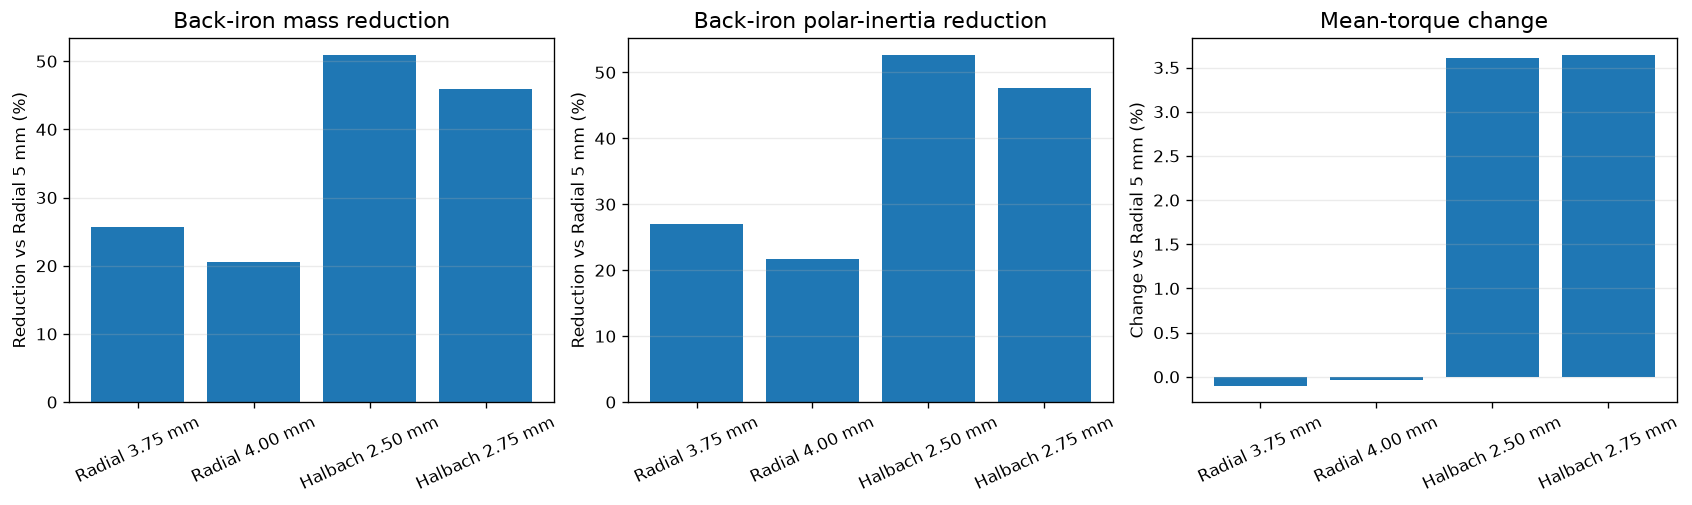

In [18]:
steel_density = 7650.0       # kg/m^3
stack_length_m = 0.150
back_iron_inner_radius_m = 0.070

candidate_torque = {
    "Radial 5.00 mm": maps["Radial"].query("current_peak_A == 50").torque_Nm.mean(),
    "Radial 3.75 mm": yoke_validation_summary.query("Design == 'Radial' and `Yoke thickness (mm)` == 3.75")["Mean torque (N·m)"].iloc[0],
    "Radial 4.00 mm": yoke_validation_summary.query("Design == 'Radial' and `Yoke thickness (mm)` == 4.00")["Mean torque (N·m)"].iloc[0],
    "Halbach 2.50 mm": yoke_validation_summary.query("Design == '3-seg Halbach' and `Yoke thickness (mm)` == 2.50")["Mean torque (N·m)"].iloc[0],
    "Halbach 2.75 mm": yoke_validation_summary.query("Design == '3-seg Halbach' and `Yoke thickness (mm)` == 2.75")["Mean torque (N·m)"].iloc[0],
}
candidate_thickness = {name: float(name.split()[-2]) for name in candidate_torque}

rows = []
for name, torque in candidate_torque.items():
    thickness_m = candidate_thickness[name] / 1000
    outer_radius = back_iron_inner_radius_m + thickness_m
    mass = steel_density*np.pi*stack_length_m*(outer_radius**2-back_iron_inner_radius_m**2)
    inertia = 0.5*mass*(outer_radius**2+back_iron_inner_radius_m**2)
    rows.append({"Candidate": name, "Back-iron thickness (mm)": 1000*thickness_m,
                 "Rotor OD (mm)": 2000*outer_radius, "Back-iron mass (kg)": mass,
                 "Back-iron polar inertia (kg·m²)": inertia, "Mean torque (N·m)": torque,
                 "Torque/back-iron mass (N·m/kg)": torque/mass})

back_iron_mechanical_summary = pd.DataFrame(rows).set_index("Candidate")
baseline = back_iron_mechanical_summary.loc["Radial 5.00 mm"]
back_iron_mechanical_summary["Mass reduction vs Radial 5 mm (%)"] = 100*(1-back_iron_mechanical_summary["Back-iron mass (kg)"]/baseline["Back-iron mass (kg)"])
back_iron_mechanical_summary["Inertia reduction vs Radial 5 mm (%)"] = 100*(1-back_iron_mechanical_summary["Back-iron polar inertia (kg·m²)"]/baseline["Back-iron polar inertia (kg·m²)"])
back_iron_mechanical_summary["Torque change vs Radial 5 mm (%)"] = 100*(back_iron_mechanical_summary["Mean torque (N·m)"]/baseline["Mean torque (N·m)"]-1)
display(back_iron_mechanical_summary.style.format("{:.3f}"))

plot_rows = back_iron_mechanical_summary.drop(index="Radial 5.00 mm")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.1), constrained_layout=True)
axes[0].bar(plot_rows.index, plot_rows["Mass reduction vs Radial 5 mm (%)"])
axes[1].bar(plot_rows.index, plot_rows["Inertia reduction vs Radial 5 mm (%)"])
axes[2].bar(plot_rows.index, plot_rows["Torque change vs Radial 5 mm (%)"])
axes[0].set(title="Back-iron mass reduction", ylabel="Reduction vs Radial 5 mm (%)")
axes[1].set(title="Back-iron polar-inertia reduction", ylabel="Reduction vs Radial 5 mm (%)")
axes[2].set(title="Mean-torque change", ylabel="Change vs Radial 5 mm (%)")
for ax in axes:
    ax.tick_params(axis="x", rotation=25); ax.grid(axis="y", alpha=.25)
plt.show()

Halbach 2.50 mm는 Radial 5.00 mm보다 백아이언 질량이 **50.9%**, 백아이언 극관성이 **52.6%** 감소하면서 평균토크는 **3.61% 높다**. 보수적인 Halbach 2.75 mm도 질량 45.9%, 관성 47.6%를 줄이면서 평균토크는 약 3.65% 높다.

이는 Halbach의 낮은 백아이언 자속을 단순 포화 여유가 아니라 회전자 철 질량·외경·관성 저감으로 전환할 수 있음을 보여준다. 단, 전체 회전자 관성은 자석·슬리브·허브를 포함한 구조 모델에서 다시 계산해야 한다.

## 9. 종합 설계 판단

### 9.1 동일 치수 비교

- 동일한 5 mm 백아이언에서 Halbach는 평균토크가 약 1–3.4% 높다.
- 외부 누설은 약 58% 낮고 회전자 요크의 자속 부담도 크게 낮다.
- 토크와 제조비만 우선하면 Radial이 단순하고 경제적인 기준안이다.

### 9.2 백아이언 재설계 비교

- 두께를 줄일수록 모든 결과는 연속적으로 변하므로 특정 두께를 절대적인 합격·탈락점으로 취급하지 않는다.
- P99 약 1.6 T를 보수적 참고점으로 보면 Radial 약 4.0 mm, Halbach 약 2.6–2.75 mm가 대응한다.
- 경량화를 더 우선하면 Radial 3.75 mm와 Halbach 2.50 mm도 경계안으로 유지할 수 있다.
- 따라서 현재 전자기 데이터가 제시하는 최종 검토 범위는 **Radial 3.75–4.00 mm, Halbach 2.50–2.75 mm**다.

### 9.3 Halbach 채택 판단

> Halbach의 핵심 가치는 동일 치수에서의 작은 최고토크 증가보다 낮은 누설자속, 낮은 회전자 요크 자속, 얇은 백아이언과 낮은 관성을 선택할 수 있는 설계 자유도에 있다.

- 최저 제조비와 단순 조립 우선: Radial 기준안
- 작은 외경, 낮은 회전자 관성, 낮은 외부 누설과 높은 토크밀도 우선: 3분할 Halbach 재최적화안
- 최종 치수는 전자기 곡선에 구조·열·제조 안전여유를 결합해 결정한다.

## 10. 해석 한계와 후속 검증

본 보고서는 2D FEMM 정자계 해석이다. 전류를 직접 지정했기 때문에 회전속도에 따른 인버터 전압 제한과 역기전력 제한은 포함되지 않는다.

- **구조:** 회전자 원심응력, 자석 고정, 슬리브, 축방향 체결 및 가공 공차
- **열:** 동손, 철손, 자석 와전류손, 냉각 조건과 온도 상승
- **자석:** 온도별 잔류자속밀도와 감자 여유
- **속도 영역:** 위치별 자속결합, 역기전력 상수와 $d$–$q$ 인덕턴스 맵을 이용한 전압·전류 제한 토크–속도 모델
- **리플 정밀도:** 대표 고전류점의 0.1–0.2° 위치 스윕
- **재료 한계:** 실제 적용 강판의 B–H 및 철손 데이터로 1.6/1.7 T 참고선 재설정

따라서 현재 결과는 전자기 형상 비교와 후보 범위 선정에는 충분하지만 최종 양산 치수와 연속운전 성능을 단독으로 확정하지는 않는다.

## 11. 부록: 지표 정의와 데이터 구성

### 주요 지표

- **Mean torque:** 반복 끝점을 제외한 회전자 위치별 토크의 산술평균
- **Torque ripple:** $(T_{max}-T_{min})/T_{mean}\times100$ (%)
- **Fundamental peak:** 공극 방사자속밀도 공간파형 FFT의 기본파 피크
- **P99:** 철심 샘플 |B| 값의 99백분위수. 단일 격자 최대값보다 국부 메시 이상치에 덜 민감하다.
- **Max:** 샘플 중 최댓값. 국부 포화 위치 확인에 사용하되 P99와 함께 해석한다.
- **Bias-corrected position mean torque:** 각 전류 위치평균에서 동일 각도망의 0 A 평균을 뺀 값

### 각도와 데이터 처리

- 30극 모터의 전기각은 기계각의 15배다.
- 0–12° 스윕에서 12°는 반복 확인용 끝점이며 평균과 리플에는 0–11°만 사용했다.
- 15 A 정밀 스윕은 0.2°, 0–50 A 통합 스윕과 백아이언 후보 검증은 1° 간격이다.
- 원본 CSV, FEM 모델과 저장된 `.ans` 파일은 `outer_rotor_36s30p_hairpin` 폴더에 보존되어 있다.